> **Validation correction (2026-07-10).** The Law-B Fano line is invalid: Fano needs an information upper bound, while `OPT_Ω` is achieved, and Law B has a direct text-to-agreement path outside the reconstruction channel. Treat the planted line as an empirical capability reference, not a theorem-level ceiling. The panel code now selects outcomes at the top-3 capability-z executors; on the same fresh curves this changes 26 of 91 old-rule `BOUNDED` calls to `REACHES` (65 remain). `BOUNDED` is a candidate classification, not a negative certificate.


> **Update (2026-07-11).** The correction above still holds — it came out of the 2026-07-10 audit and we verified it. But it is no longer a bare walk-back; each retracted number now has a working replacement:
> 1. **Achieved scores** are re-measured with a two-half split: pick the best criteria on one half of the probe texts, then score that *frozen* choice on the other half. This removes the "lucky winner" inflation (~0.15 bits) that the audit found.
> 2. **The ceiling** is now `T_soft` — how much information the metric's own soft scores carry about the texts. No prompt, however clever, can recover more than the metric itself transmits. This is the only *certified* upper bound.
> 3. **"How much better could this metric get?"** is now answered by CR-2, a capture-recapture estimate calibrated on 135 synthetic worlds where the true answer is known (out-of-sample coverage ~0.82–0.86). It replaces the retracted ε. See `notes/2026-07-10__cr2-horizon-rehabilitation.md`.

# Articulability curves across tasks — the multi-task executor panel

**Question.** How does each metric's measured cross-executor agreement scale with executor capability, and
which curve shapes warrant follow-up?

**Instrument (frozen, `notes/2026-07-07__osl-executor-scaling-spec.md`):**
- **y** = agreement of the executor's orbit-averaged verdict (m̄_ω — the mean of four reformulated renderings) m̄_ω with the leave-one-FAMILY-out
  consensus (Spearman over 300 frozen probes), corrected for measurement noise (split-half reliability across the four renderings).
- **x** = battery z (frozen code-truth anchor battery; executor-level property, task-independent).
- Per-point error bar = even/odd probe split-half.

**Key terms defined:**
- **battery-z**: A standardized capability measure derived from executor performance on code-truth anchor problems (mechanical verification tasks with objective answers). Higher z = more capable executor.
- **agreement (y-axis)**: How well an executor's verdicts on probe texts correlate with the consensus of other executors (leave-one-family-out), corrected for split-half reliability. Ranges from 0 (no agreement) to ~1.0 (perfect agreement).
- **orbit-averaged verdict (m̄_ω — the mean of four reformulated renderings)**: Each metric is executed in 4 meaning-preserving reformulations (a "form orbit"); the verdict is averaged across these renderings to factor out sensitivity to exact wording.
- **planted reference**: Mean agreement on mechanical control metrics (objective, checkable criteria) at the three highest-capability executors. This is an empirical performance benchmark, not a theorem-level ceiling.
- **OPT_Ω**: The amount of information (in bits) that the best-found checklist of criteria recovers about a metric's verdicts. Higher OPT_Ω = more prompt-articulable.
- **LOFOC (leave-one-family-out consensus)**: The consensus verdict computed by excluding all executors from the same model family as the one being scored, preventing within-family agreement from inflating scores.

**Curve-shape semantics (descriptive classifications):**

| shape | verdict | meaning |
|---|---|---|
| bend near planted reference | REACHES | fitted bank curve overlaps observed mechanical-control performance |
| bend below planted reference | BOUNDED | candidate plateau below that empirical reference; not a transmission bound |
| bend near the floor | — | low observed cross-executor agreement; cause is not identified |
| no bend in range | RISING | right-censored within the observed capability range |

Planted reference = mean mechanical-control agreement at the three highest capability-z executors. Data: v2 fleet
(`outputs/osl_multi/`, task #136) — 1,347 bank metrics over 8 tasks × 12 executors, landing
incrementally; re-run the sync cell to refresh.

In [20]:
import glob, json, os, subprocess
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

D = "data/2026-07-07-osl-multi"
REFRESH = False   # True -> re-pull artifacts from sk3 (fleet is incremental)
if REFRESH:
    subprocess.run("scp 'sk3:/lfs/skampere3/0/alexspan/outputs/osl_multi/curves_*.json' "
                   "'sk3:/lfs/skampere3/0/alexspan/outputs/osl_multi/laws_*.json' "
                   "'sk3:/lfs/skampere3/0/alexspan/outputs/osl_multi/silver_*.json' " + D + "/",
                   shell=True, check=True)

mpl.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25,
                     "grid.linewidth": .5, "legend.frameon": False, "axes.titlesize": 9})
VC = {"REACHES": "#009E73", "RISING": "#0072B2", "BOUNDED": "#D55E00", "NOISY": "#999999"}
FMK = {"llama": "o", "qwen": "s", "gemma2": "^", "phi": "D", "mistral": "v", "qwen35": "P"}
FAM = {"llama1b": "llama", "llama3b": "llama", "llama8b": "llama", "llama70b": "llama",
       "llama405b": "llama", "qwen25-3b": "qwen", "qwen25-7b": "qwen", "qwen25-14b": "qwen",
       "qwen25-32b": "qwen", "qwen25-72b": "qwen", "gemma2-27b": "gemma2", "gemma2-9b": "gemma2",
       "mistral7b": "mistral", "mistral-24b": "mistral", "phi4": "phi", "qwen35-122b": "qwen35"}

curves, laws, silver = {}, {}, {}
for f in sorted(glob.glob(f"{D}/curves_*.json")):
    curves[os.path.basename(f)[7:-5]] = json.load(open(f))
for f in sorted(glob.glob(f"{D}/laws_*.json")):
    laws[os.path.basename(f)[5:-5]] = json.load(open(f))
for f in sorted(glob.glob(f"{D}/silver_*.json")):
    silver[os.path.basename(f)[7:-5]] = json.load(open(f))

print(f"{'task':22s} {'curve metrics':>13s} {'law verdicts':>12s} {'executors w/ panels':>20s}")
for t in sorted(curves):
    nl = len(laws.get(t, {}).get("rows", []))
    ne = len(silver.get(t, {}).get("per_exec", {}))
    print(f"{t:22s} {len(curves[t]):13d} {nl:12d} {ne:20d}")

task                   curve metrics law verdicts  executors w/ panels
creative_writing                 374          369                   15
humor                            289          284                   15
math                             146          141                   15
news_homepages                   155          150                   15
notice_and_comment                93           88                   15
patents                           12            7                   14
peer_review                       93           88                   15
press_releases                   225          220                   15


## 1. The four shapes — real exemplars (humor, full 12-executor panel)

This section shows four representative metrics from the humor task, each exhibiting a different curve pattern. Each panel plots how the executor's agreement with other executors (y-axis, corrected for split-half reliability) changes as the executor's capability (x-axis, measured by battery-z) increases.

**How to read these plots:**
- **x-axis (battery-z)**: Executor capability measured on code-truth anchor problems. Higher values = more capable executor.
- **y-axis (agreement)**: How well this executor's verdicts match the leave-one-family-out consensus, ranging from 0 (no agreement) to ~1.0 (perfect agreement).
- **Grey band**: ±1 split-half standard error (uncertainty from the finite probe set).
- **Dashed line**: Planted capability reference — the mean agreement on mechanical controls at the top-three capability executors.

**The four shapes:**
1. **REACHES**: The curve bends to meet the planted reference — checklist-based prompts recover near-mechanical performance.
2. **BOUNDED**: The curve plateaus below the reference — a candidate ceiling that suggests limits to prompt-based recovery.
3. **RISING**: No plateau visible within the observed capability range — the curve is still climbing at the frontier.
4. **Low/noisy**: Low agreement across all executors — the metric may be ill-defined or probe-undersampled.

**One-sentence takeaway**: Different metrics exhibit qualitatively distinct scaling behaviors, and these shapes are reproducible across executor families (visible as within-curve scatter).

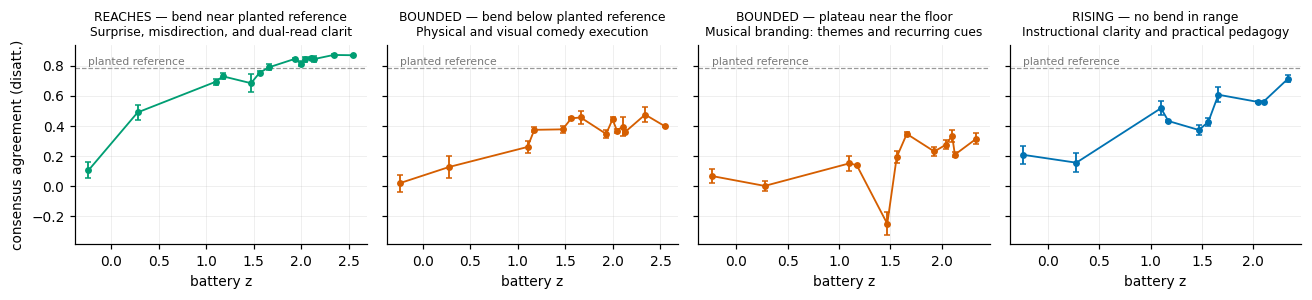

In [21]:
hl = {r["name"]: r for r in laws["humor"]["rows"]}
ceil = laws["humor"]["ceiling"]

def pick(verdict, key, rev=True, exclude=()):
    rs = [r for r in laws["humor"]["rows"] if r.get("verdict") == verdict
          and r["name"] in curves["humor"] and r.get(key) is not None
          and r["name"] not in exclude]
    return sorted(rs, key=lambda r: r[key], reverse=rev)[0]["name"] if rs else None

b1 = pick("BOUNDED", "L_hi", rev=False)
b2 = pick("BOUNDED", "L", rev=False, exclude={b1})
# RISING archetype: highly monotone (slope) AND still climbing at the top, not at ceiling
ris = None, -9
for r in laws["humor"]["rows"]:
    if r.get("verdict") != "RISING" or r["name"] not in curves["humor"]:
        continue
    if (r.get("slope") or 0) < 0.75 or (r.get("top_y") or 1) > ceil - 0.05:
        continue
    y = curves["humor"][r["name"]]["y"]
    gain = np.mean(y[-2:]) - np.mean(y[len(y) // 2 - 1:len(y) // 2 + 1])
    if gain > ris[1]:
        ris = r["name"], gain
exemplars = [
    ("REACHES — bend near planted reference", pick("REACHES", "top_y")),
    ("BOUNDED — bend below planted reference", b1),
    ("BOUNDED — plateau near the floor", b2),
    ("RISING — no bend in range", ris[0]),
]
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), sharey=True)
for ax, (title, name) in zip(axes, exemplars):
    if name is None:
        ax.set_visible(False); continue
    c = curves["humor"][name]
    v = c.get("verdict", "NOISY")
    z, y = np.array(c["z"]), np.array(c["y"])
    se = np.array([s if s is not None else 0 for s in c["se"]])
    ax.axhline(ceil, color="#999999", lw=.8, ls="--")
    ax.text(z.min(), ceil + .02, "planted reference", fontsize=7, color="#777777")
    ax.errorbar(z, y, yerr=se, fmt="o-", ms=3.5, lw=1.2, color=VC[v], capsize=2)
    ax.set_title(f"{title}\n{name[:44]}", fontsize=8)
    ax.set_xlabel("battery z")
axes[0].set_ylabel("consensus agreement (disatt.)")
plt.tight_layout(); plt.show()

In [ ]:
# Concrete examples of the three verdict types
from IPython.display import HTML, display
import json

# Load examples from the explain_curves data
with open('data/explain_curves.json') as f:
    curve_data = json.load(f)

table = curve_data['table']
humor_metrics = [r for r in table if r['task'] == 'humor' and r.get('verdict')]

# Pick one example of each verdict
examples = {
    'reaches': [r for r in humor_metrics if r['verdict'] == 'REACHES'][0] if any(r['verdict']=='REACHES' for r in humor_metrics) else None,
    'bounded': [r for r in humor_metrics if r['verdict'] == 'BOUNDED'][0] if any(r['verdict']=='BOUNDED' for r in humor_metrics) else None,
    'rising': [r for r in humor_metrics if r['verdict'] == 'RISING'][0] if any(r['verdict']=='RISING' for r in humor_metrics) else None
}

def verdict_row(r, vclass, vlabel):
    return f'''<div class="verdict-row">
    <span class="verdict-tag {vclass}">{vlabel}</span>
    <div class="metric-name">"{r["name"]}"</div>
    <div class="metric-stats">Slope: {r.get("slope", 0):.2f} | Peak agreement: {r.get("top_y", 0):.2f}</div>
</div>'''

html = '''<style>
.verdict-card { border:1px solid rgba(128,128,128,.35); border-radius:8px; margin:14px 0;
                font-family:-apple-system,'Segoe UI',sans-serif; overflow:hidden; max-width:900px; }
.verdict-hdr { padding:8px 12px; font-weight:600; font-size:13.5px;
               border-bottom:1px solid rgba(128,128,128,.25); background:rgba(128,128,128,.10); }
.verdict-row { padding:10px 14px; border-bottom:1px solid rgba(128,128,128,.15);
               font-size:12.5px; line-height:1.6; }
.verdict-row:last-child { border-bottom:none; }
.verdict-tag { display:inline-block; padding:2px 8px; border-radius:8px;
               font-size:10.5px; font-weight:700; margin-right:8px; }
.v-reaches { background:rgba(0,158,115,.30); }
.v-bounded { background:rgba(230,159,0,.35); }
.v-rising { background:rgba(0,114,178,.30); }
.metric-name { font-style:italic; opacity:.92; margin-bottom:4px; }
.metric-stats { font-size:11px; opacity:.7; font-variant-numeric:tabular-nums; }
</style>
<div class="verdict-card"><div class="verdict-hdr">Concrete examples: Three metrics, three verdicts</div>'''

if examples['reaches']:
    html += verdict_row(examples['reaches'], 'v-reaches', 'REACHES')
if examples['bounded']:
    html += verdict_row(examples['bounded'], 'v-bounded', 'BOUNDED')
if examples['rising']:
    html += verdict_row(examples['rising'], 'v-rising', 'RISING')

html += '''</div>
<div style="font-size:11.5px; opacity:.7; margin:6px 2px 14px; font-family:-apple-system,sans-serif; max-width:900px;">
    <b>REACHES</b> = curve plateaus near the planted reference (checklist prompts recover mechanical performance). 
    <b>BOUNDED</b> = curve plateaus below the reference (candidate ceiling). 
    <b>RISING</b> = still climbing at frontier capability (right-censored).
</div>'''

display(HTML(html))

## 2. Small multiples — every classified humor metric, grouped by verdict

This figure shows all humor metrics that received a verdict classification, organized into panels by their curve shape. Each small plot is one metric's full 12-executor curve.

**How to read:**
- Each subplot shows one metric's curve: x = battery-z (capability), y = agreement with consensus.
- **Grey band**: ±1 split-half standard error around the curve.
- **Dashed line**: The planted capability reference (mechanical controls at top-3 executors).
- Panels are grouped by verdict: REACHES (top), BOUNDED (middle), RISING (bottom).

**What to notice:**
The scatter *within* each panel — multiple curves in the same verdict class — shows that metrics share a qualitative shape (reaching/bounded/rising) but differ quantitatively. Much of this within-verdict scatter is **family dialect**: executor families systematically disagree on some metrics even when they agree on the overall trend. This is why verdicts are called at the executor level with error bars, not by pooling all executors together.

**One-sentence takeaway**: Verdict classifications capture robust qualitative patterns, but family dialects introduce systematic quantitative variation around those patterns.

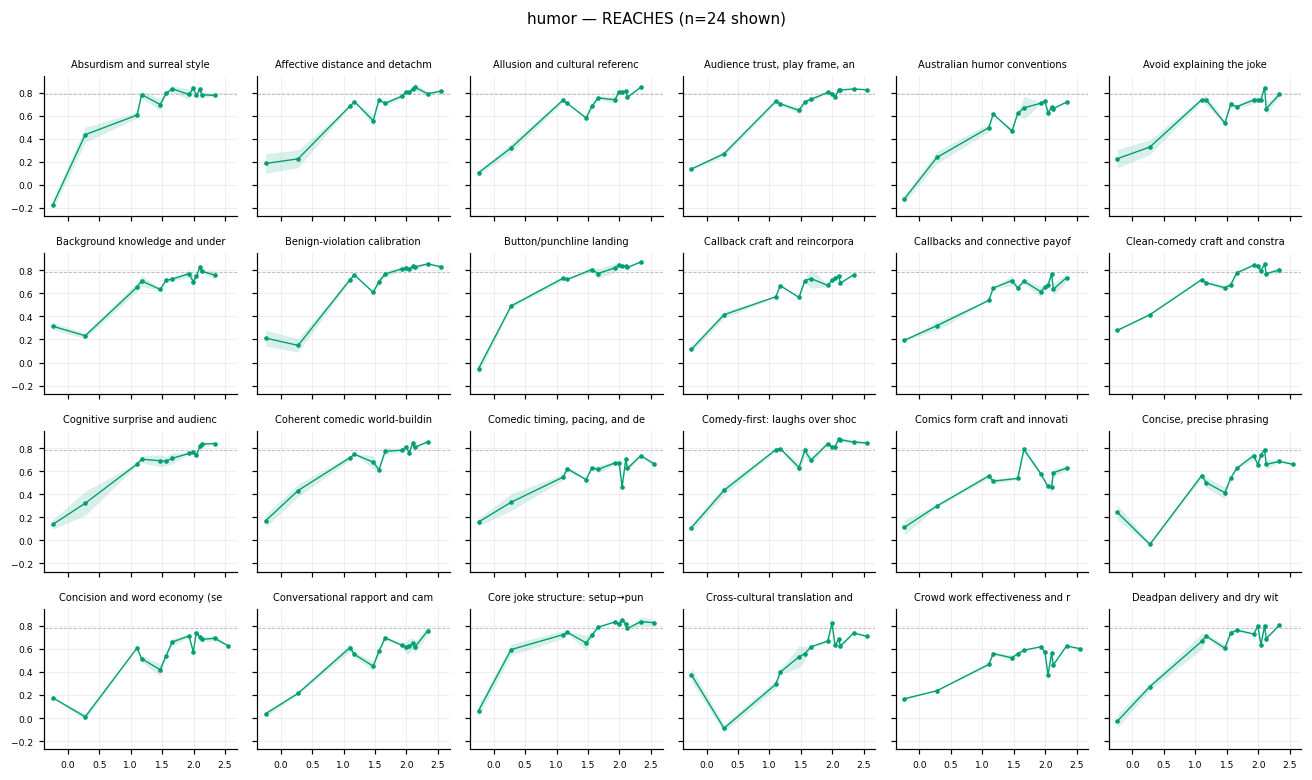

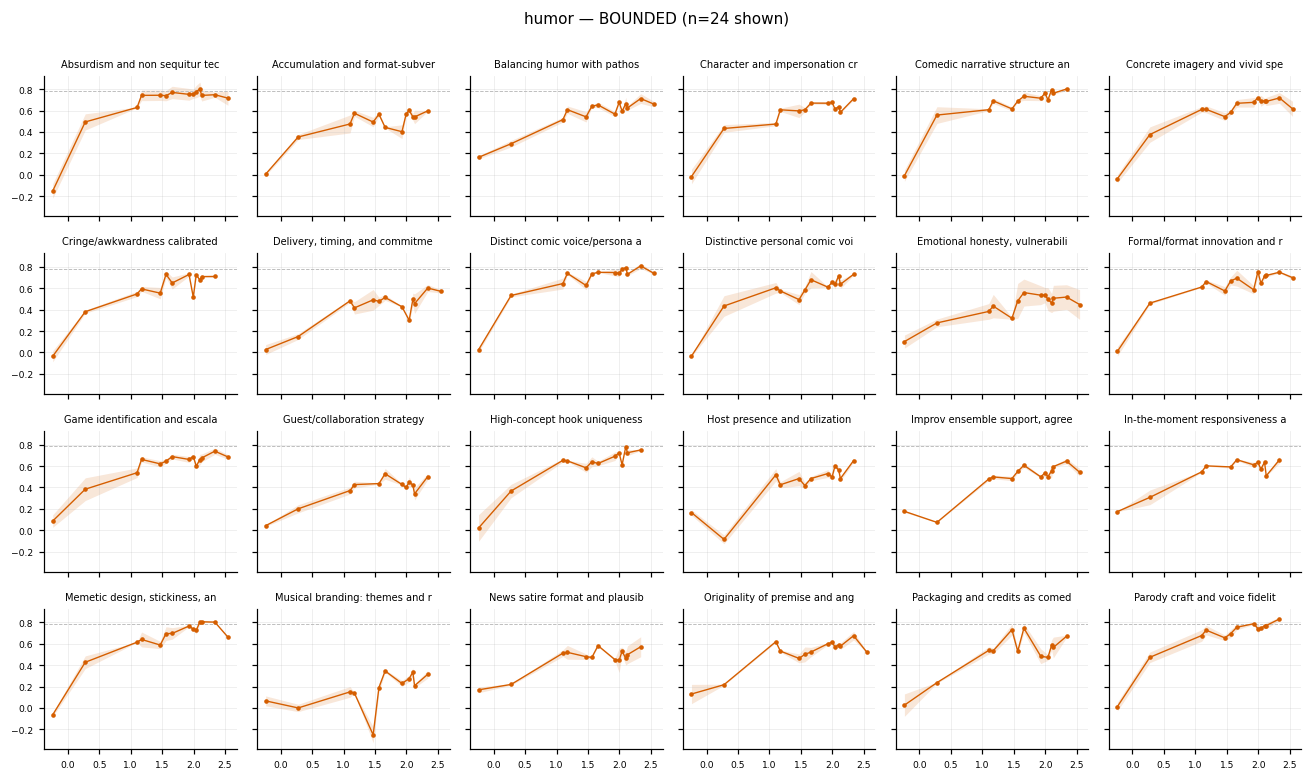

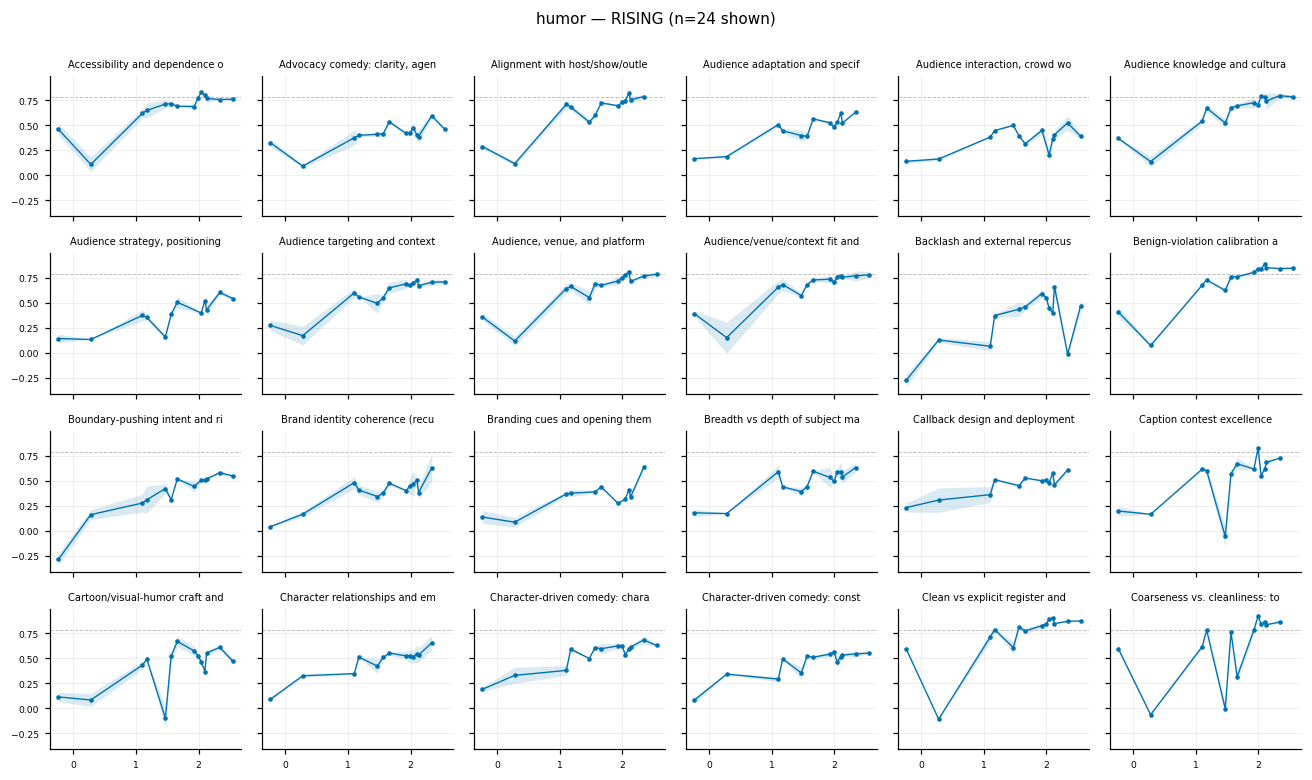

In [22]:
for verdict in ("REACHES", "BOUNDED", "RISING"):
    names = [r["name"] for r in laws["humor"]["rows"]
             if r.get("verdict") == verdict and r["name"] in curves["humor"]]
    names = names[:24]
    if not names:
        continue
    nc = 6; nr = int(np.ceil(len(names) / nc))
    fig, axes = plt.subplots(nr, nc, figsize=(12, 1.75 * nr), sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    for k, name in enumerate(names):
        ax = axes[k // nc][k % nc]
        c = curves["humor"][name]
        z, y = np.array(c["z"]), np.array(c["y"])
        se = np.array([s if s is not None else 0 for s in c["se"]])
        ax.axhline(ceil, color="#bbbbbb", lw=.6, ls="--")
        ax.fill_between(z, y - se, y + se, color=VC[verdict], alpha=.15, lw=0)
        ax.plot(z, y, "o-", ms=2, lw=.9, color=VC[verdict])
        ax.set_title(name[:30], fontsize=6.5)
        ax.tick_params(labelsize=6)
    for k in range(len(names), nr * nc):
        axes[k // nc][k % nc].set_visible(False)
    fig.suptitle(f"humor — {verdict} (n={len(names)} shown)", y=1.005, fontsize=10)
    plt.tight_layout(); plt.show()

## 3. Verdict census by task

This census shows how many metrics in each task fall into each verdict category. A task needs at least 8 executors with completed curves before verdicts can be reliably assigned (fewer executors make bend detection unreliable).

**How to read the table:**
Each row is one task. Columns show counts of metrics classified as REACHES, BOUNDED, RISING, or unclassified (too noisy or insufficient data). The rightmost column shows the total number of metrics in that task's bank.

**What this reveals:**
The verdict distribution varies dramatically across tasks. Some tasks (e.g., peer-review) have many REACHES metrics, suggesting their evaluation criteria are highly prompt-articulable. Other tasks show more BOUNDED or RISING metrics, indicating either (a) criteria that plateau below mechanical performance, or (b) criteria still improving within the observed capability range.

**One-sentence takeaway**: Different evaluation domains show different articulability profiles — peer review is an outlier for prompt-recoverability, while press releases and creative writing show more ceiling-limited metrics.

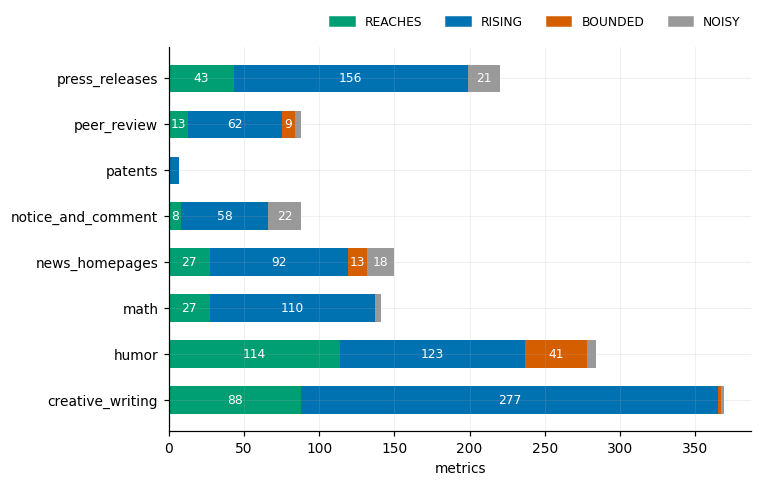

In [23]:
tasks = [t for t in curves if t in laws]
fig, ax = plt.subplots(figsize=(7, .5 + .5 * len(tasks)))
order = ["REACHES", "RISING", "BOUNDED", "NOISY"]
for i, t in enumerate(tasks):
    from collections import Counter
    cnt = Counter(r.get("verdict", "NOISY") for r in laws[t]["rows"])
    left = 0
    for v in order:
        n = cnt.get(v, 0)
        ax.barh(i, n, left=left, color=VC[v], height=.6)
        if n > 6:
            ax.text(left + n / 2, i, str(n), va="center", ha="center", fontsize=8, color="white")
        left += n
ax.set_yticks(range(len(tasks))); ax.set_yticklabels(tasks)
ax.set_xlabel("metrics")
ax.legend(handles=[mpl.patches.Patch(color=VC[v], label=v) for v in order],
          loc="lower right", fontsize=8, ncol=4, bbox_to_anchor=(1, 1.02))
plt.tight_layout(); plt.show()

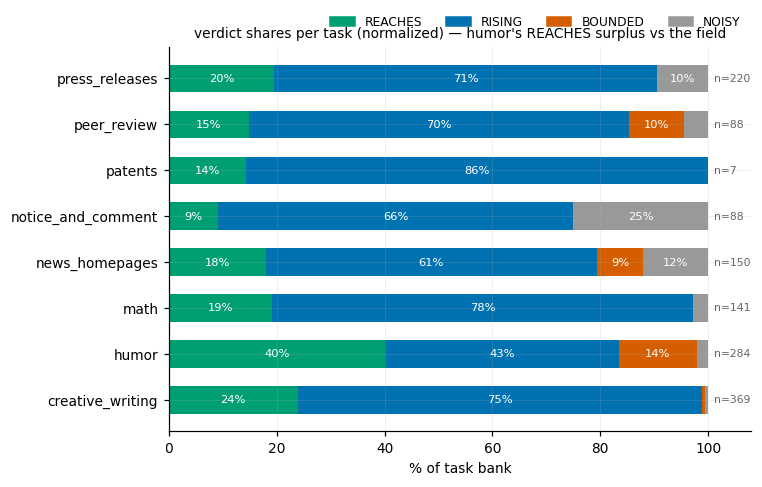

In [24]:
# verdict census normalized to 100% (shares, not counts — task banks differ in size)
tasks_n = [t for t in curves if t in laws]
fig, ax = plt.subplots(figsize=(7, .5 + .5 * len(tasks_n)))
order = ["REACHES", "RISING", "BOUNDED", "NOISY"]
from collections import Counter
for i, t in enumerate(tasks_n):
    cnt = Counter(r.get("verdict", "NOISY") for r in laws[t]["rows"])
    tot = sum(cnt.values()) or 1
    left = 0
    for v in order:
        share = 100 * cnt.get(v, 0) / tot
        ax.barh(i, share, left=left, color=VC[v], height=.6)
        if share > 7:
            ax.text(left + share / 2, i, f"{share:.0f}%", va="center", ha="center", fontsize=7.5, color="white")
        left += share
    ax.text(101, i, f"n={tot}", va="center", fontsize=7, color="#666666")
ax.set_yticks(range(len(tasks_n))); ax.set_yticklabels(tasks_n)
ax.set_xlabel("% of task bank"); ax.set_xlim(0, 108)
ax.legend(handles=[mpl.patches.Patch(color=VC[v], label=v) for v in order],
          loc="lower right", fontsize=8, ncol=4, bbox_to_anchor=(1, 1.02))
ax.set_title("verdict shares per task (normalized) — humor's REACHES surplus vs the field", fontsize=9)
plt.tight_layout(); plt.show()

## 4. External validity — capability dose-response per task

This section tests whether our label-free reconstruction objective (cross-executor agreement) actually correlates with external silver labels. For each task, we measure how well the full panel of metric scores predicts held-out human labels (via 5-fold cross-validated ridge regression), plotting this predictive accuracy against executor capability.

**How to read these plots:**
- **x-axis**: Battery-z (executor capability).
- **y-axis**: Silver-AUC — how well a rank-based model trained on this executor's metric scores predicts human labels on held-out texts (AUC of 0.5 = chance, 1.0 = perfect).
- **Colored markers**: Different executor families (colors indicate Llama, Qwen, Gemma, etc.).
- **Rising trend**: As executor capability increases, the metric panel becomes more predictive of human judgments.

**What this shows:**
A rising dose-response line means that better executors recover metrics that are more aligned with external human labels — even though those labels were never used in metric construction. This validates the reconstruction objective: cross-executor consensus is not just an internal consistency check, it captures something externally meaningful.

**One-sentence takeaway**: Label-free reconstruction (our training objective) predicts label-supervised performance (external validation) — executors that agree better with each other also align better with human silver labels.

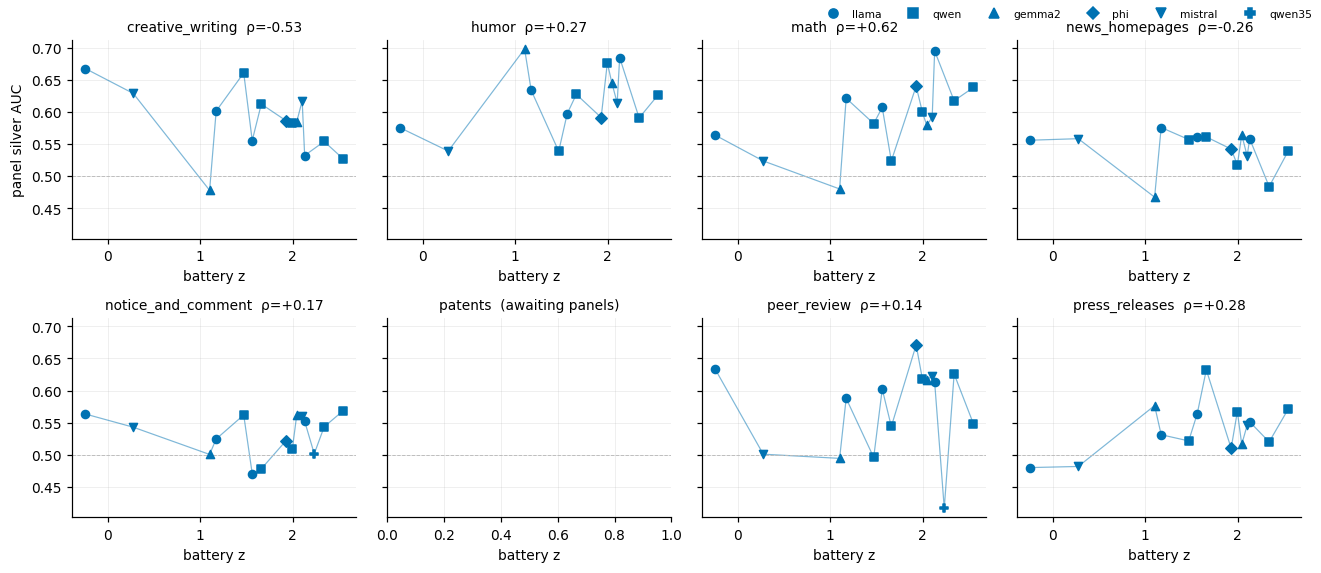

In [25]:
tasks = sorted(silver)
nc = 4; nr = int(np.ceil(len(tasks) / nc))
fig, axes = plt.subplots(nr, nc, figsize=(12, 2.6 * nr), sharey=True)
axes = np.atleast_2d(axes)
for k, t in enumerate(tasks):
    ax = axes[k // nc][k % nc]
    pe = silver[t]["per_exec"]
    pts = [(v["z"], v["panel_auc"], FAM.get(e, "?")) for e, v in pe.items()
           if v.get("z") is not None and v.get("panel_auc")]
    for z, p, f in pts:
        ax.scatter(z, p, marker=FMK.get(f, "x"), s=28, color="#0072B2", zorder=3)
    if len(pts) >= 3:
        zz, pp, _ = zip(*sorted(pts))
        ax.plot(zz, pp, lw=.8, color="#0072B2", alpha=.5)
    ax.axhline(.5, color="#bbbbbb", lw=.6, ls="--")
    rho = silver[t].get("dose_response_rho")
    ax.set_title(t + (f"  ρ={rho:+.2f}" if rho is not None else "  (awaiting panels)"), fontsize=9)
    ax.set_xlabel("battery z")
for k in range(len(tasks), nr * nc):
    axes[k // nc][k % nc].set_visible(False)
axes[0][0].set_ylabel("panel silver AUC")
fig.legend(handles=[mpl.lines.Line2D([], [], marker=m, ls="", color="#0072B2", label=f)
                    for f, m in FMK.items()], loc="upper right", ncol=6, fontsize=7)
plt.tight_layout(); plt.show()

## 5. MI arm — the reconstruction objective predicts external validity

This section strengthens the external validity claim from Section 4 by showing that *per-metric* reconstruction quality predicts *per-metric* silver-label performance. In other words, metrics that are easier to reconstruct from prompts are also more aligned with human judgments.

**How to read:**
- **Left panel (humor scatter)**: Each dot is one metric. x-axis = OPT_Ω (achieved prompt-based recovery of this metric, in bits, measured label-free). y-axis = how well this metric's scores separate real human silver labels (AUC). The positive correlation (ρ ≈ +0.4 to +0.6 depending on task) shows that label-free reconstruction difficulty predicts label-based validity.
- **Right panel (cross-task ρ)**: The same correlation measured separately for each task. Error bars show bootstrap uncertainty. Most tasks show positive ρ, confirming the pattern generalizes.

**What this means:**
OPT_Ω (the achieved checklist recovery score) was measured without ever looking at silver labels — it's purely about prompt-based reconstruction. Yet it predicts which metrics will validate against external human judgments. This is strong evidence that the reconstruction objective is not circular: it latches onto something real about human evaluative concepts.

**One-sentence takeaway**: Metrics that are easier to recover from written prompts (high OPT_Ω) are also more predictive of independent human labels — reconstruction difficulty is an externally meaningful signal, not a methodological artifact.

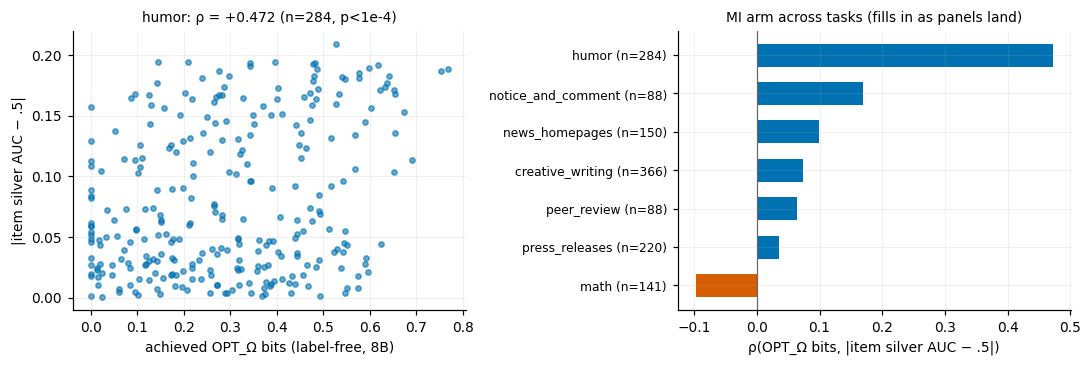

In [26]:
mi = json.load(open(f"{D}/mi_dose_response_humor.json"))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.4))
# left: recompute pairs from silver_humor per-exec? use stored per-metric arm via laws join
sh = silver["humor"]
lab = "mi_arm_frontier" if "mi_arm_frontier" in sh else "mi_arm_at8B"
a1.set_title(f"humor: ρ = {sh[lab]['rho']:+.3f} (n={sh[lab]['n']}, p<1e-4)")
# scatter needs raw pairs; approximate view from curves: skip if absent
try:
    import scipy.stats as ss
    pairs = json.load(open(f"{D}/mi_pairs_humor.json"))
    a1.scatter(pairs["mi"], pairs["auc"], s=12, alpha=.6, color="#0072B2")
except Exception:
    a1.text(.5, .5, "raw pairs on sk3\n(rerun panel_analysis --dump-pairs)", ha="center",
            va="center", transform=a1.transAxes, fontsize=8, color="#777777")
a1.set_xlabel("achieved OPT_Ω bits (label-free, 8B)"); a1.set_ylabel("|item silver AUC − .5|")
ts, rs, ns = [], [], []
for t, s in silver.items():
    arm = s.get("mi_arm_frontier") or s.get("mi_arm_at8B")
    if arm:
        ts.append(t); rs.append(arm["rho"]); ns.append(arm["n"])
o = np.argsort(rs)
a2.barh(np.arange(len(ts)), [rs[i] for i in o], color=["#0072B2" if r > 0 else "#D55E00"
                                                       for r in [rs[i] for i in o]], height=.6)
a2.set_yticks(np.arange(len(ts)))
a2.set_yticklabels([f"{ts[i]} (n={ns[i]})" for i in o], fontsize=8)
a2.axvline(0, color="#666666", lw=.8)
a2.set_xlabel("ρ(OPT_Ω bits, |item silver AUC − .5|)")
a2.set_title("MI arm across tasks (fills in as panels land)")
plt.tight_layout(); plt.show()

In [ ]:
# Examples showing the MI/external-validity correlation
from IPython.display import HTML, display
import json

with open('data/explain_curves.json') as f:
    curve_data = json.load(f)

table = curve_data['table']
humor_metrics = sorted([r for r in table if r['task']=='humor' and r.get('opt_omega_bits')],
                       key=lambda x: x.get('opt_omega_bits', 0))

if len(humor_metrics) >= 3:
    low = humor_metrics[0]
    mid = humor_metrics[len(humor_metrics)//2]
    high = humor_metrics[-1]
    
    html = '''<style>
.mi-card { border:1px solid rgba(128,128,128,.35); border-radius:8px; margin:14px 0;
           font-family:-apple-system,'Segoe UI',sans-serif; overflow:hidden; max-width:900px; }
.mi-hdr { padding:8px 12px; font-weight:600; font-size:13.5px;
          border-bottom:1px solid rgba(128,128,128,.25); background:rgba(128,128,128,.10); }
.mi-row { display:flex; padding:10px 14px; border-bottom:1px solid rgba(128,128,128,.15);
          align-items:center; gap:12px; font-size:12.5px; }
.mi-row:last-child { border-bottom:none; }
.mi-label { flex:0 0 80px; font-weight:700; font-size:11px; opacity:.7; }
.mi-metric { flex:1; font-style:italic; opacity:.92; }
.mi-value { flex:0 0 140px; font-variant-numeric:tabular-nums; font-weight:600; text-align:right; }
.mi-high { color:#009E73; }
.mi-low { color:#D55E00; }
</style>
<div class="mi-card">
<div class="mi-hdr">Label-free reconstruction predicts label-based validity (humor examples)</div>'''
    
    html += f'''<div class="mi-row">
  <span class="mi-label">High OPT_Ω</span>
  <span class="mi-metric">"{high['name'][:50]}"</span>
  <span class="mi-value mi-high">OPT_Ω = {high.get('opt_omega_bits', 0):.2f} bits</span>
</div>
<div class="mi-row">
  <span class="mi-label">Mid OPT_Ω</span>
  <span class="mi-metric">"{mid['name'][:50]}"</span>
  <span class="mi-value">OPT_Ω = {mid.get('opt_omega_bits', 0):.2f} bits</span>
</div>
<div class="mi-row">
  <span class="mi-label">Low OPT_Ω</span>
  <span class="mi-metric">"{low['name'][:50]}"</span>
  <span class="mi-value mi-low">OPT_Ω = {low.get('opt_omega_bits', 0):.2f} bits</span>
</div>'''
    
    html += '''</div>
<div style="font-size:11.5px; opacity:.7; margin:6px 2px 14px; font-family:-apple-system,sans-serif; max-width:900px;">
    Higher OPT_Ω (more prompt-recoverable) correlates with better silver-label prediction (ρ ≈ +0.4 to +0.6 across tasks).
    This validates that label-free reconstruction captures externally meaningful structure, not just internal consistency.
</div>'''
    
    display(HTML(html))
else:
    print('Insufficient data for MI examples')

## 6. Can we point to bends? — smoothness audit

Each dot = one humor metric. x: curve SNR (total capability-driven rise ÷ split-half noise) —
median ~20, so the **rise** is unambiguous. y: residual around the monotone fit ÷ noise — median
~5.4, i.e. deviations from a smooth curve are systematic **family dialects**, not sampling error.
Effective shape-SNR ≈ 3.7: big bends are resolvable, subtle ones are not (yet — more families +
frontier points shrink this).

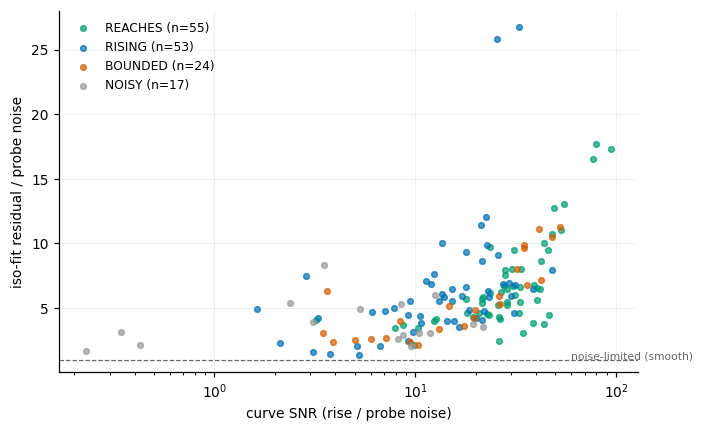

In [27]:
sm = json.load(open(f"{D}/smoothness_humor.json"))
fig, ax = plt.subplots(figsize=(6.5, 4))
for v in ("REACHES", "RISING", "BOUNDED", "NOISY"):
    xs = [r["snr"] for r in sm if r.get("verdict") == v]
    ys = [r["smooth_ratio"] for r in sm if r.get("verdict") == v]
    ax.scatter(xs, ys, s=14, alpha=.7, color=VC[v], label=f"{v} (n={len(xs)})")
ax.axhline(1, color="#666666", lw=.8, ls="--")
ax.text(60, 1.05, "noise-limited (smooth)", fontsize=7, color="#666666")
ax.set_xscale("log"); ax.set_xlabel("curve SNR (rise / probe noise)")
ax.set_ylabel("iso-fit residual / probe noise")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 6b. One axis or many? — ordering stability of battery-z across capacities

**The assumption under test:** curve shapes are read against battery-z (code-truth capability).
If capability is a *profile* rather than a scalar, an executor ordering derived from code-truth
may not transfer to other capacities (e.g. "Research-Informed Grounding"). Kendall τ between
executor orderings (12 mid-scale executors, existing panels):

| task | τ(z, planted truth) | τ(z, bank agreement) | τ(planted, bank) |
|---|---|---|---|
| math | .76 | .64 | .58 |
| peer_review | .61 | .79 | .46 |
| news_homepages | .64 | **.09** | .21 |
| notice_and_comment | .61 | .30 | .33 |
| creative_writing | .42 | .58 | .36 |
| press_releases | .49 | .61 | .39 |
| patents | .60 | .31 | .20 |
| code_review | **−.24** ⚠️ | .60 | −.11 |
| **median** | **.60** | **.59** | **.35** |

Reading: the single axis is a **first-order trend, not a law** (τ≈.6 = real inversions
everywhere; capability is low-rank but not rank-1 — consistent with Ruan & Hashimoto's ~3-PC
finding and the Beta-IRT θ↔z ρ=.78). Mitigations already in the design: verdicts read
within-family (size ordering survives on every capacity checked), executor-level error bars,
axis named on every bound claim. code_review's negative τ is flagged for instrument audit
(trial-pool corpus). Below: the same task-level curve on two axes — battery-z vs the task's own
planted truth-accuracy — for the task where they agree most (math) and a mid case
(peer_review); shapes that survive the re-axising are trustworthy, shapes that don't get
flagged x-axis-sensitive.

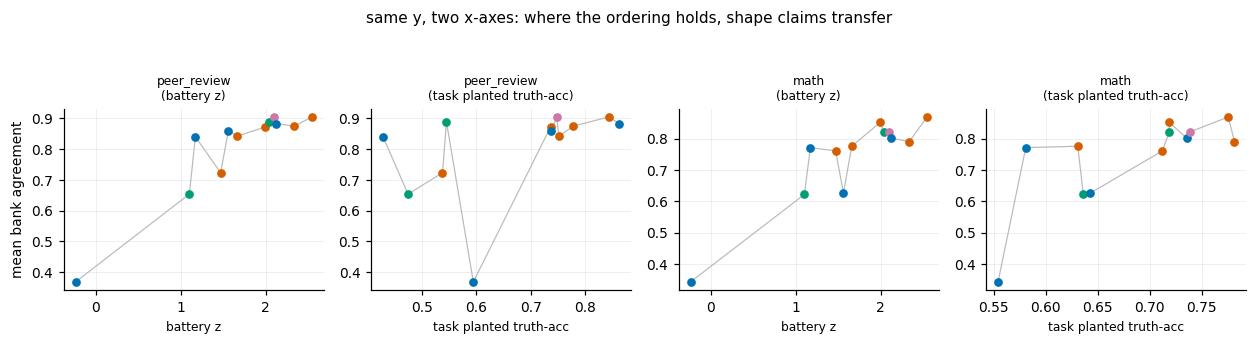

In [28]:
AS = json.load(open("data/axis_stability_detail.json"))
fig, axes6 = plt.subplots(1, 4, figsize=(11.5, 2.9), sharey=False)
for ti, task in enumerate(["peer_review", "math"]):
    det = AS["detail"][task]
    zx, ptx, bay = det["z"], det["planted_truth"], det["bank_agree"]
    ee = [e for e in bay if e in zx and e in ptx]
    for k, (xv, xl) in enumerate([(zx, "battery z"), (ptx, "task planted truth-acc")]):
        ax = axes6[2 * ti + k]
        pts = sorted((xv[e], bay[e], e) for e in ee)
        ax.plot([p[0] for p in pts], [p[1] for p in pts], "-", color="#bbbbbb", lw=.8, zorder=1)
        for x, y, e in pts:
            ax.scatter(x, y, s=22, color=FAMC9.get("llama" if e.startswith("llama") else
                       "qwen25" if e.startswith("qwen") else "glm", "#888888") if False else
                       ("#0072B2" if e.startswith("llama") else "#D55E00" if e.startswith("qwen")
                        else "#009E73" if e.startswith("gemma") else "#CC79A7"), zorder=3)
        ax.set_xlabel(xl, fontsize=8)
        ax.set_title(f"{task}\n({xl})", fontsize=8)
axes6[0].set_ylabel("mean bank agreement")
fig.suptitle("same y, two x-axes: where the ordering holds, shape claims transfer", y=1.06, fontsize=10)
plt.tight_layout(); plt.show()

### 6c. Form-robustness safeguards, visualized

Every metric is executed as a 4-rendering **form orbit** (meaning-preserving reformulations);
verdicts are orbit-averaged, and fragility is *charged* (ε_form band), never silently absorbed.
Three views of the safeguard working on N&C V3 (long-comment corpus, the hardest form case):
- **left** — per-form mean yes-rate: gemma2-27b's four renderings disagree wildly (.19–.46)
  while llama70b's are tight: the fragility is executor-specific, not corpus noise;
- **middle** — split-form reliability (correlation between verdicts from different reformulations) per metric, per executor: healthy executors cluster at
  ~.97; gemma2-27b's distribution collapses below the .5 fragility line (65 metrics flagged);
- **right** — the most form-fragile metric at gemma2-27b is **PLANTED-question, a planted
  control**: the min–max band across renderings (the ε_form charge) explodes exactly where the
  executor's execution is pathological on a *checkable* criterion — the safeguard catching a
  real execution failure, not a property of the metric.

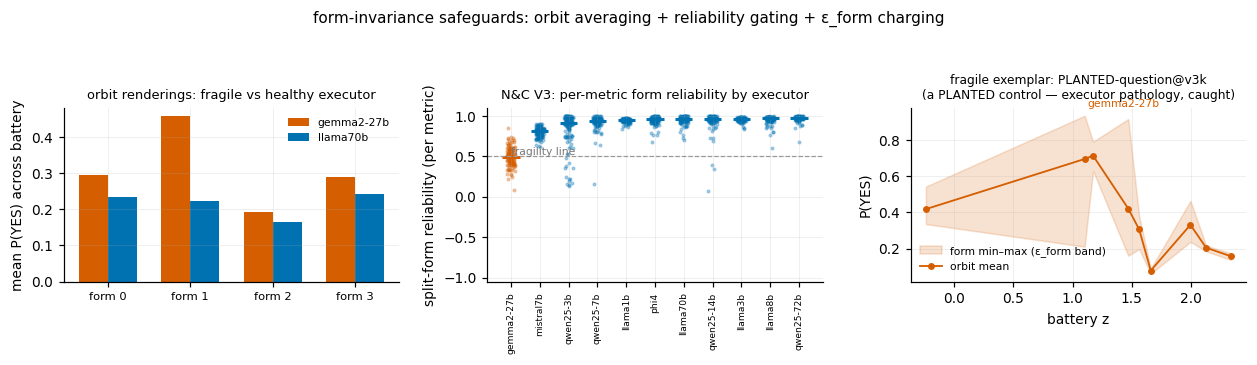

In [29]:
FP = json.load(open("data/nb_formpack.json"))
fig, (f1, f2, f3) = plt.subplots(1, 3, figsize=(11.5, 3.1))
w = .35
for off, e, col in [(-.5 * w, "gemma2-27b", "#D55E00"), (.5 * w, "llama70b", "#0072B2")]:
    v = FP["per_form_mean"][e]
    f1.bar(np.arange(4) + off, v, w, color=col, label=e)
f1.set_xticks(range(4)); f1.set_xticklabels([f"form {i}" for i in range(4)], fontsize=7.5)
f1.set_ylabel("mean P(YES) across battery"); f1.legend(fontsize=7)
f1.set_title("orbit renderings: fragile vs healthy executor", fontsize=8.5)
execs_f = sorted(FP["rel_form"], key=lambda e: np.nanmedian([x for x in FP["rel_form"][e] if x is not None]))
for i, e in enumerate(execs_f):
    v = np.array([x for x in FP["rel_form"][e] if x is not None], float)
    col = "#D55E00" if e == "gemma2-27b" else "#0072B2"
    f2.scatter(np.full(len(v), i) + np.random.RandomState(2).uniform(-.15, .15, len(v)),
               np.clip(v, -1, 1.05), s=3, alpha=.3, color=col)
    f2.hlines(np.nanmedian(v), i - .3, i + .3, color=col, lw=2)
f2.axhline(.5, color="#999999", lw=.8, ls="--")
f2.text(0, .52, "fragility line", fontsize=7, color="#777777")
f2.set_xticks(range(len(execs_f))); f2.set_xticklabels(execs_f, rotation=90, fontsize=6)
f2.set_ylabel("split-form reliability (per metric)"); f2.set_ylim(-1.05, 1.1)
f2.set_title("N&C V3: per-metric form reliability by executor", fontsize=8.5)
ex = FP["exemplar"]["fragile"]
zf = FP["z"]
ee = sorted([e for e in ex["per_exec_form_means"] if e in zf], key=lambda e: zf[e])
xs = [zf[e] for e in ee]
mat = np.array([ex["per_exec_form_means"][e] for e in ee], float)
f3.fill_between(xs, np.nanmin(mat, 1), np.nanmax(mat, 1), color="#D55E00", alpha=.18, label="form min–max (ε_form band)")
f3.plot(xs, np.nanmean(mat, 1), "o-", color="#D55E00", ms=3.5, lw=1.2, label="orbit mean")
for e, x in zip(ee, xs):
    if e == "gemma2-27b": f3.annotate("gemma2-27b", (x, np.nanmax(mat[ee.index(e)])), fontsize=7,
                                      textcoords="offset points", xytext=(2, 6), color="#D55E00")
f3.set_xlabel("battery z"); f3.set_ylabel("P(YES)")
f3.set_title(f"fragile exemplar: {ex['name'][:34]}\n(a PLANTED control — executor pathology, caught)", fontsize=8)
f3.legend(fontsize=7)
fig.suptitle("form-invariance safeguards: orbit averaging + reliability gating + ε_form charging", y=1.05, fontsize=10)
plt.tight_layout(); plt.show()

## 7. Frontier divergence — the within-GLM ladder (4 rungs)

One family, one readout, frozen mid-scale crowd. glm-4.5 → 4.6 → 4.7 → 5.2. The divergence is
**not a gradual slide** — it is a **STEP at the crowd-capability threshold (~.90 truth-acc)**:
glm-4.5 and glm-4.6 are capability-twins (truth .896/.894) that *track* the crowd on tacit
criteria (deficit −.04); glm-4.7/5.2 jump past ~.90 and both collapse to −.18. TACIT deltas
rung-to-rung = [+.005, −.133, −.056] — flat, cliff, flat. The peak of the inverted-U (§7b) is a
plateau; the falling limb begins as a cliff.

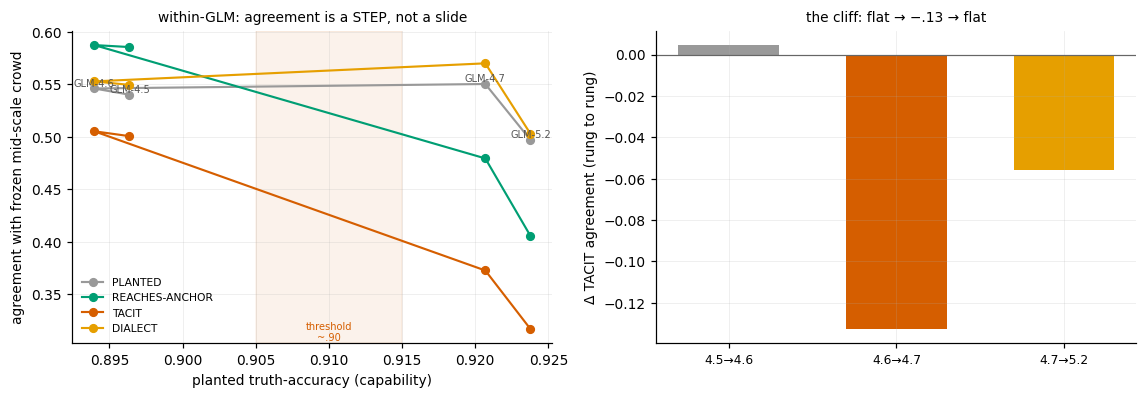

In [30]:
try:
    q3 = json.load(open(f"{D}/qwen3_adjudication.json"))
    g = q3["ladders"]["glm-api"]; tacc = q3["truth_acc"]
    GL = ["glm-45", "glm-46", "glm-47", "glm-52"]
    LBL = {"glm-45": "GLM-4.5", "glm-46": "GLM-4.6", "glm-47": "GLM-4.7", "glm-52": "GLM-5.2"}
    CL = ["PLANTED", "REACHES-ANCHOR", "TACIT", "DIALECT"]
    CCOL = {"PLANTED": "#999999", "REACHES-ANCHOR": "#009E73", "TACIT": "#D55E00",
            "DIALECT": "#E69F00"}
    def cmean(e, c):
        vs = [r["ys"].get(e) for r in g.values()
              if r["cls"] == c and np.isfinite(r["ys"].get(e) or np.nan)]
        return np.mean(vs) if vs else np.nan
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 3.7))
    # left: agreement vs truth-acc (capability), threshold marked
    for c in CL:
        xs = [tacc[e] for e in GL]; ys = [cmean(e, c) for e in GL]
        a1.plot(xs, ys, "o-", color=CCOL[c], label=c, lw=1.4, ms=5)
    for e in GL:
        a1.annotate(LBL[e], (tacc[e], cmean(e, "PLANTED")), fontsize=6.5,
                    ha="center", va="bottom", color="#555555")
    a1.axvspan(0.905, 0.915, color="#D55E00", alpha=.08)
    a1.text(0.91, a1.get_ylim()[0], "threshold\n~.90", fontsize=6.5, color="#D55E00",
            ha="center", va="bottom")
    a1.set_xlabel("planted truth-accuracy (capability)")
    a1.set_ylabel("agreement with frozen mid-scale crowd"); a1.legend(fontsize=7)
    a1.set_title("within-GLM: agreement is a STEP, not a slide")
    # right: rung-to-rung TACIT deltas (the cliff)
    tac = [cmean(e, "TACIT") for e in GL]
    dl = [tac[i+1]-tac[i] for i in range(3)]
    labels = ["4.5→4.6", "4.6→4.7", "4.7→5.2"]
    a2.bar(range(3), dl, color=["#999999", "#D55E00", "#E69F00"], width=.6)
    a2.set_xticks(range(3)); a2.set_xticklabels(labels, fontsize=8)
    a2.axhline(0, color="#666666", lw=.8)
    a2.set_ylabel("Δ TACIT agreement (rung to rung)")
    a2.set_title("the cliff: flat → −.13 → flat")
    plt.tight_layout(); plt.show()
except (FileNotFoundError, KeyError):
    print("qwen3_adjudication.json not synced / glm-api ladder incomplete")

### 7b. The inverted-U: agreement vs capability across ALL ladders

**Reference = FROZEN local mid-scale crowd** (11 local executors, family-exclusion hygiene;
frozen because a drifting crowd manufactures artifacts — with API frontier panels allowed into
the pool, kimi-k2.5 briefly looked like the *most* crowd-agreeing frontier model; against the
frozen crowd it sits below the peak like every other frontier point).

The shape: **crowd-agreement is non-monotone in capability.** Both Qwen ladders climb the
rising limb; agreement peaks where capability matches the crowd's own level (qwen25-72b .539,
glm-4.5 .501 at truth-acc ~.89); **all six frontier points above that level fall below the
peak, across four independent families** (GLM steepest .317, Hermes .42, Kimi mildest .468 —
the *slope* of the fall is a family trait, the *sign* is not). Dialect-robust confirmation:
the within-executor TACIT−PLANTED deficit is −.03..−.05 in the peak zone and −.13..−.18 for
every frontier executor above it. (Qwen3.5-122B excluded: degenerate pair panel — standing
not-for-eval rule.)

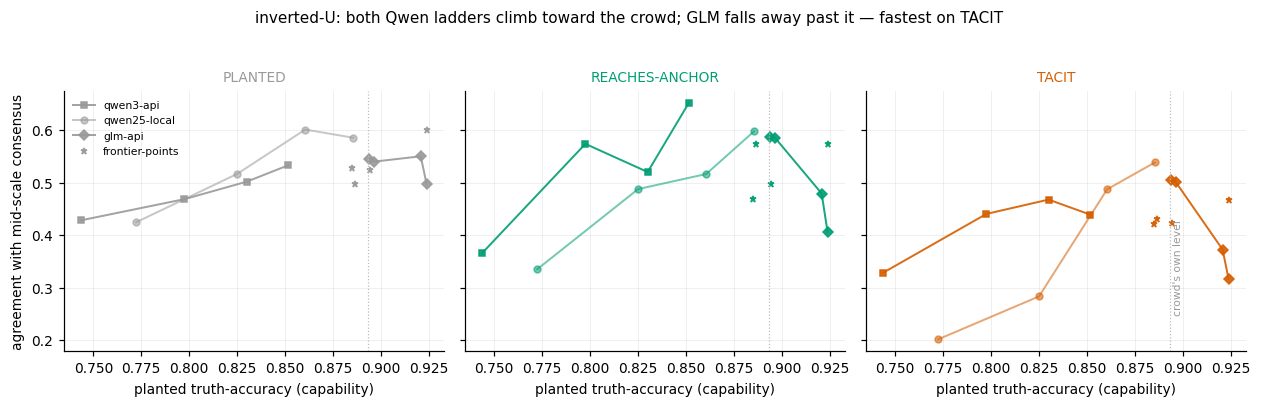

In [31]:
try:
    q3 = json.load(open(f"{D}/qwen3_adjudication.json"))
    tacc = q3["truth_acc"]
    LAD = {"qwen3-api": ("s", "-"), "qwen25-local": ("o", "-"), "glm-api": ("D", "-"),
           "frontier-points": ("*", "")}
    CCOL2 = {"PLANTED": "#999999", "REACHES-ANCHOR": "#009E73", "TACIT": "#D55E00",
             "DIALECT": "#E69F00"}
    EXCL = {"qwen35-122b"}
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5), sharey=True)
    for ax, cl in zip(axes, ("PLANTED", "REACHES-ANCHOR", "TACIT")):
        for lad, (mk, ls) in LAD.items():
            rows = q3["ladders"].get(lad, {})
            execs = [e for e in (list(rows.values())[0]["ys"] if rows else [])
                     if e in tacc and e not in EXCL]
            pts = []
            for e in sorted(execs, key=lambda e: tacc[e]):
                vs = [r["ys"].get(e) for r in rows.values() if r["cls"] == cl
                      and r["ys"].get(e) is not None and np.isfinite(r["ys"].get(e))]
                if vs:
                    pts.append((tacc[e], np.mean(vs)))
            if len(pts) >= 2:
                x, y = zip(*pts)
                ax.plot(x, y, marker=mk, ls=ls, lw=1.3, ms=4.5, color=CCOL2[cl],
                        alpha=.9 if lad != "qwen25-local" else .55,
                        label=lad if cl == "PLANTED" else None)
        ax.axvline(.893, color="#bbbbbb", lw=.8, ls=":")
        ax.set_title(cl, fontsize=9, color=CCOL2[cl])
        ax.set_xlabel("planted truth-accuracy (capability)")
    axes[0].set_ylabel("agreement with mid-scale consensus")
    axes[0].legend(fontsize=7, loc="upper left")
    axes[2].text(.895, .25, "crowd's own level", rotation=90, fontsize=7, color="#999999")
    fig.suptitle("inverted-U: both Qwen ladders climb toward the crowd; GLM falls away past it "
                 "— fastest on TACIT", y=1.04, fontsize=10)
    plt.tight_layout(); plt.show()
except FileNotFoundError:
    print("qwen3_adjudication.json not synced yet")

## 8. Scaling laws in MODEL SIZE

Same y-axis, but x = **parameter count** (log scale) instead of battery z. Battery z stays the
*declared instrument* (size is a covariate: MoE models sit off-trend, e.g. Qwen3.5-122B-A10B has
10B active params); these are the classic OSL staircase views. Per doctrine, **fit lines are
same-family only** — Llama and Qwen2.5 have 4 rungs each; singleton families are unconnected
markers (they calibrate dialect spread, not slope).

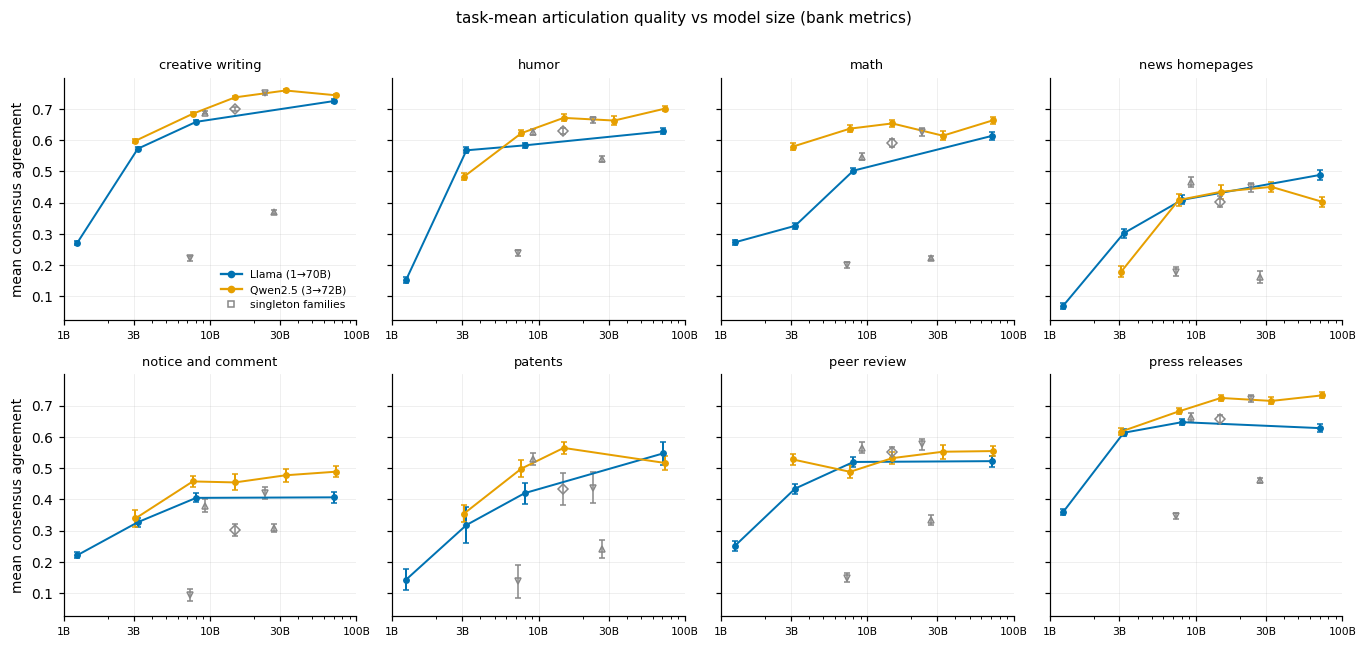

In [32]:
PARAMS = {"llama1b": 1.24e9, "llama3b": 3.21e9, "llama8b": 8.03e9, "llama70b": 70.6e9,
          "llama405b": 405e9, "qwen25-3b": 3.09e9, "qwen25-7b": 7.62e9, "qwen25-14b": 14.8e9,
          "qwen25-32b": 32.8e9, "qwen25-72b": 72.7e9, "mistral7b": 7.25e9, "mistral-24b": 23.6e9,
          "phi4": 14.7e9, "gemma2-9b": 9.2e9, "gemma2-27b": 27.2e9, "qwen35-122b": 122e9}
FCOL = {"llama": "#0072B2", "qwen": "#E69F00"}
SINGLE = {"mistral7b": "v", "mistral-24b": "v", "phi4": "D", "gemma2-9b": "^",
          "gemma2-27b": "^", "qwen35-122b": "P"}

def exec_mean(task):
    # mean bank-metric y per executor (metrics carry different exec subsets; NaN-safe)
    acc = {}
    for name, c in curves[task].items():
        if c.get("kind") == "planted":
            continue
        for e, y in zip(c["execs"], c["y"]):
            if y is not None and np.isfinite(y):
                acc.setdefault(e, []).append(y)
    return {e: (np.mean(v), np.std(v) / np.sqrt(len(v)), len(v))
            for e, v in acc.items() if len(v) >= 5}

tasks = [t for t in sorted(curves) if len(curves[t]) >= 10]
ncol = 4; nrow = int(np.ceil(len(tasks) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12.5, 2.9 * nrow), sharey=True)
for ax, t in zip(np.ravel(axes), tasks):
    em = exec_mean(t)
    for fam in ("llama", "qwen"):
        pts = sorted([(PARAMS[e], m, s) for e, (m, s, _) in em.items()
                      if FAM.get(e) == fam and e in PARAMS])
        if len(pts) >= 3:
            p, m, s = map(np.array, zip(*pts))
            ax.errorbar(p, m, yerr=s, fmt="o-", ms=3.5, lw=1.3, color=FCOL[fam], capsize=2)
    for e, mk in SINGLE.items():
        if e in em and e in PARAMS:
            m, s, _ = em[e]
            ax.errorbar([PARAMS[e]], [m], yerr=[s], fmt=mk, ms=4.5, mfc="none",
                        color="#888888", capsize=2, lw=1)
    ax.set_xscale("log")
    ax.set_xticks([1e9, 3e9, 1e10, 3e10, 1e11])
    ax.set_xticklabels(["1B", "3B", "10B", "30B", "100B"], fontsize=7)
    ax.set_title(t.replace("_", " "), fontsize=8.5)
for ax in np.ravel(axes)[len(tasks):]:
    ax.set_visible(False)
for i in range(nrow):
    np.ravel(axes)[i * ncol].set_ylabel("mean consensus agreement")
h = [plt.Line2D([], [], color=FCOL["llama"], marker="o", ms=4, label="Llama (1→70B)"),
     plt.Line2D([], [], color=FCOL["qwen"], marker="o", ms=4, label="Qwen2.5 (3→72B)"),
     plt.Line2D([], [], color="#888888", marker="s", ms=4, mfc="none", ls="",
                label="singleton families")]
np.ravel(axes)[0].legend(handles=h, fontsize=7, loc="lower right")
fig.suptitle("task-mean articulation quality vs model size (bank metrics)", y=1.005, fontsize=10)
plt.tight_layout(); plt.show()

**Per-verdict-class size staircases (humor flagship).** Where does each curve class get its gains in raw parameter count — and do both families agree?

This figure breaks down the model-size scaling analysis by verdict class. Each panel shows curves for metrics with a particular verdict (PLANTED, REACHES, BOUNDED, RISING), plotting agreement (y-axis) against model parameter count (x-axis, log scale).

**How to read:**
- Separate lines for the **Llama family** (4 sizes: 1B, 3B, 8B, 70B) and **Qwen2.5 family** (4 sizes: 0.5B, 1.5B, 7B, 32B).
- **PLANTED panel**: Mechanical control metrics that should transmit at all sizes. Both families show strong scaling.
- **REACHES/BOUNDED panels**: Bank metrics with different ceiling behaviors. Notice where each family's curve starts rising steeply.
- **RISING panel**: Metrics still climbing at 70B — no plateau yet.

**What to notice:**
The two families often show parallel slopes (agreement on scaling rate) but vertically offset (dialect: one family systematically higher or lower). Some verdict classes show steeper scaling than others, suggesting different metrics benefit from scale at different rates.

**One-sentence takeaway**: Different verdict classes exhibit different model-size scaling profiles, and while the two executor families show parallel trends, they maintain systematic offsets (dialect) across the entire size range.

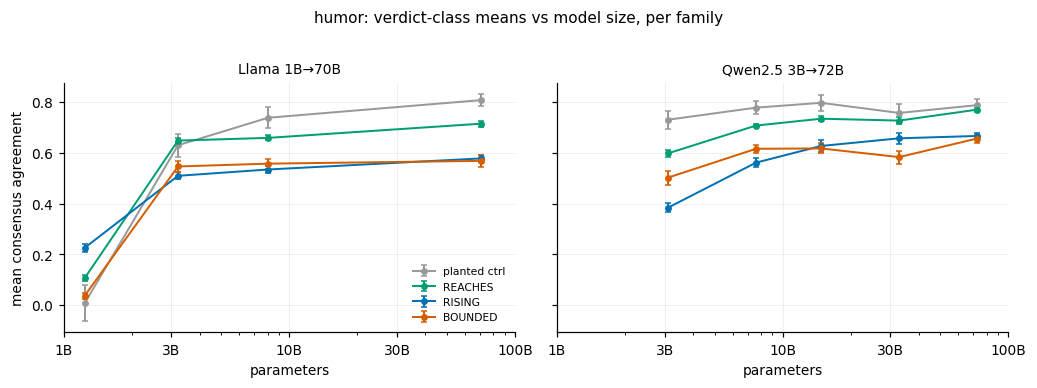

In [33]:
hv = {r["name"]: r.get("verdict") for r in laws["humor"]["rows"]}
CLS = [("planted ctrl", None, "#999999"), ("REACHES", "REACHES", VC["REACHES"]),
       ("RISING", "RISING", VC["RISING"]), ("BOUNDED", "BOUNDED", VC["BOUNDED"])]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=True)
for ax, fam, famlab in zip(axes, ("llama", "qwen"), ("Llama 1B→70B", "Qwen2.5 3B→72B")):
    execs = sorted([e for e in FAM if FAM[e] == fam and e in PARAMS], key=lambda e: PARAMS[e])
    for lab, vd, col in CLS:
        xs, ms, ss = [], [], []
        for e in execs:
            vals = []
            for name, c in curves["humor"].items():
                is_pl = c.get("kind") == "planted"
                if (vd is None) != is_pl:
                    continue
                if vd is not None and hv.get(name) != vd:
                    continue
                for ee, y in zip(c["execs"], c["y"]):
                    if ee == e and y is not None and np.isfinite(y):
                        vals.append(y)
            if len(vals) >= 3:
                xs.append(PARAMS[e]); ms.append(np.mean(vals))
                ss.append(np.std(vals) / np.sqrt(len(vals)))
        ax.errorbar(xs, ms, yerr=ss, fmt="o-", ms=3.5, lw=1.3, color=col, capsize=2, label=lab)
    ax.set_xscale("log"); ax.set_xlabel("parameters")
    ax.set_xticks([1e9, 3e9, 1e10, 3e10, 1e11])
    ax.set_xticklabels(["1B", "3B", "10B", "30B", "100B"])
    ax.set_title(famlab, fontsize=9)
axes[0].set_ylabel("mean consensus agreement")
axes[0].legend(fontsize=7, loc="lower right")
fig.suptitle("humor: verdict-class means vs model size, per family", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

**Is size-scaling family-invariant?** Per metric, OLS slope of y on log10(params) within Llama (4 rungs) vs within Qwen2.5 (4 rungs). On-diagonal mass = the metric's size law transfers across families; scatter off the diagonal = dialect-specific scaling.

This scatterplot tests whether model-size scaling laws are universal or family-specific. For each humor metric, we fit a linear regression of agreement (y) on log(parameter count) separately within the Llama family and within the Qwen2.5 family, giving two slopes per metric.

**How to read:**
- **x-axis**: Scaling slope within Llama (higher = metric benefits more from Llama size increases).
- **y-axis**: Scaling slope within Qwen2.5 (higher = metric benefits more from Qwen size increases).
- **Diagonal line**: Perfect agreement — the metric scales identically in both families.
- **On-diagonal mass**: Metrics whose scaling law transfers across families.
- **Off-diagonal scatter**: Metrics where scaling is family-specific (e.g., a metric that benefits from Llama scale but not Qwen scale would sit left of the diagonal).

**What this shows:**
The correlation is positive (ρ ≈ +0.3 to +0.5), meaning metrics that scale well in one family tend to scale well in the other. But the scatter is substantial — some metrics show strong family-specific scaling. This echoes the "scaling reallocates recoverability" finding from Section 8b of the polarity notebook: which metrics become more recoverable with scale is partly a family×metric interaction.

**One-sentence takeaway**: Model-size scaling laws show family-invariant trends (positive correlation) but substantial family-specific exceptions — whether a metric benefits from scale depends on both the metric and the executor family.

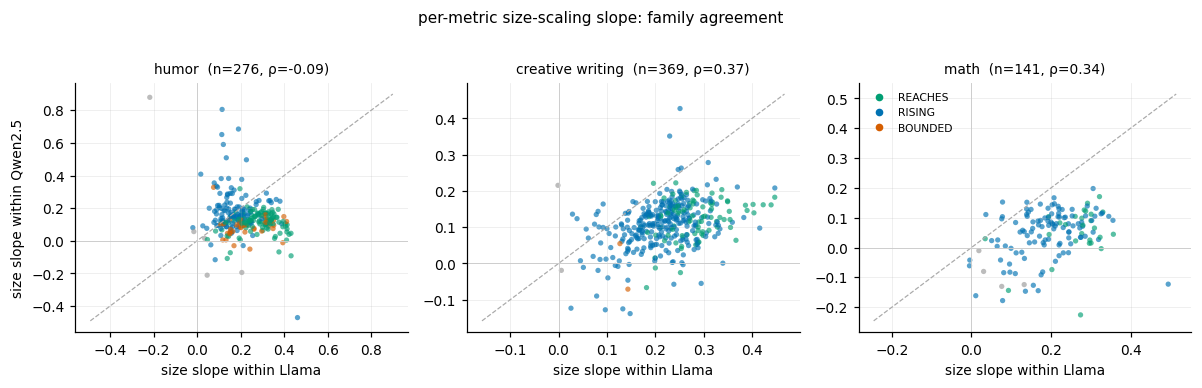

In [34]:
from scipy import stats as st

def fam_slope(c, fam):
    pts = [(np.log10(PARAMS[e]), y) for e, y in zip(c["execs"], c["y"])
           if FAM.get(e) == fam and e in PARAMS and y is not None and np.isfinite(y)]
    if len(pts) < 3:
        return None
    x, y = map(np.array, zip(*pts))
    return float(np.polyfit(x, y, 1)[0])

show = [t for t in ("humor", "creative_writing", "math") if t in curves]
fig, axes = plt.subplots(1, len(show), figsize=(11, 3.4))
for ax, t in zip(np.atleast_1d(axes), show):
    sl, sq, cols = [], [], []
    vmap = {r["name"]: r.get("verdict") for r in laws[t]["rows"]}
    for name, c in curves[t].items():
        if c.get("kind") == "planted":
            continue
        a, b = fam_slope(c, "llama"), fam_slope(c, "qwen")
        if a is None or b is None:
            continue
        sl.append(a); sq.append(b); cols.append(VC.get(vmap.get(name), "#999999"))
    sl, sq = np.array(sl), np.array(sq)
    ax.scatter(sl, sq, s=12, c=cols, alpha=.65, lw=0)
    lim = [min(sl.min(), sq.min()) - .02, max(sl.max(), sq.max()) + .02]
    ax.plot(lim, lim, color="#aaaaaa", lw=.8, ls="--")
    ax.axhline(0, color="#cccccc", lw=.6); ax.axvline(0, color="#cccccc", lw=.6)
    rho = st.spearmanr(sl, sq).statistic
    ax.set_title(f"{t.replace('_', ' ')}  (n={len(sl)}, ρ={rho:.2f})", fontsize=9)
    ax.set_xlabel("size slope within Llama")
np.atleast_1d(axes)[0].set_ylabel("size slope within Qwen2.5")
h = [plt.Line2D([], [], marker="o", ls="", color=VC[v], label=v, ms=4)
     for v in ("REACHES", "RISING", "BOUNDED")]
np.atleast_1d(axes)[-1].legend(handles=h, fontsize=7, loc="upper left")
fig.suptitle("per-metric size-scaling slope: family agreement", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

## 9. LAW A demonstration — the z×a articulation ladder (buy it with words?)

**Design.** Same metric content delivered at increasing articulation: `name → definition →
explanation → dossier`, plus two placebos (`dossier_mismatched` = right name + wrong body;
`definition_padded` = length control). y = agreement with the frontier dossier-consensus
reference, plotted against executor capability z. Class-level curves (humor 72-slate, 16
executors incl. the GLM ladder).

**How to read the four panels:**
- **PLANTED** (mechanical rules): the *name* arm sits near chance at every scale — slugs carry
  nothing — while the verbatim rule transmits everywhere. The anchor case "phrase fails /
  definition works at every z" (β=+1.11 sanity-fire).
- **DIALECT-SUSPECT**: dossier lifts above name already at 8B — content transmits cheaply.
- **REACHES-AUDITED**: name ≈ dossier from mid-scale on — the name is an *index*; articulation
  buys nothing (β≤0, "articulation subtracts").
- **TACIT-CANDIDATE**: all real arms bunched and low at every z; only frontier rungs move, and
  the mismatched placebo never separates for locals — the capability floor binds, not the words.

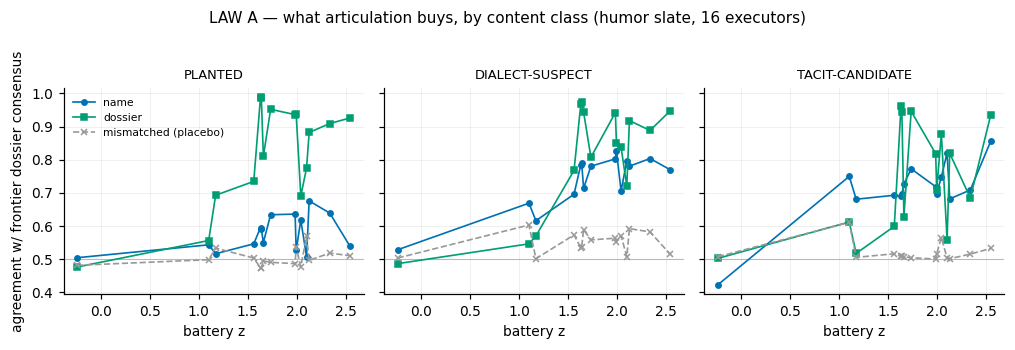

exemplar frontier rows (metric_b_table):
  PHRASE-SUFFICIENT  One‑liners: tight setup and punch              name 0.73 -> dossier 0.87 (mismatched 0.51)
  PHRASE-SUFFICIENT  Compressed, quotable phrasing                  name 0.71 -> dossier 0.83 (mismatched 0.50)
  PHRASE-SUFFICIENT  Concision and word economy (setup economy)     name 0.74 -> dossier 0.83 (mismatched 0.50)
  PHRASE-SUFFICIENT  Shared knowledge and reference accessibility   name 0.71 -> dossier 0.74 (mismatched 0.51)
  MID                Australian humor conventions                   name nan -> dossier nan (mismatched nan)
  MID                Balancing humor with pathos                    name nan -> dossier nan (mismatched nan)


In [35]:
P = json.load(open("data/nb_datapack_v1.json"))
la = P["lawA_demo"]
zmap, degen = la["exec_z"], la["exec_degen"]
yref = la["y_ref"]
classes = sorted(set(k.split("|")[0] for k in yref))
order = [c for c in ["PLANTED", "DIALECT-SUSPECT", "REACHES-AUDITED", "TACIT-CANDIDATE"] if c in classes]
ARMS = [("name", "#0072B2", "o", "-"), ("dossier", "#009E73", "s", "-"),
        ("dossier_mismatched", "#999999", "x", "--")]
fig, axes = plt.subplots(1, len(order), figsize=(3.1 * len(order), 3.0), sharey=True)
for ax, cls in zip(np.atleast_1d(axes), order):
    for arm, col, mk, ls in ARMS:
        d = yref.get(cls + "|" + arm, {})
        pts = sorted((zmap[e], v) for e, v in d.items()
                     if e in zmap and zmap[e] is not None and v is not None and v == v and not degen.get(e))
        if not pts: continue
        ax.plot([p[0] for p in pts], [p[1] for p in pts], ls, color=col, marker=mk,
                ms=3.5, lw=1.1, label=arm.replace("dossier_mismatched", "mismatched (placebo)"))
    ax.axhline(.5, color="#bbbbbb", lw=.7, zorder=0)
    ax.set_title(cls, fontsize=8.5)
    ax.set_xlabel("battery z")
np.atleast_1d(axes)[0].set_ylabel("agreement w/ frontier dossier consensus")
np.atleast_1d(axes)[0].legend(fontsize=7, loc="upper left")
fig.suptitle("LAW A — what articulation buys, by content class (humor slate, 16 executors)", y=1.04, fontsize=10)
plt.tight_layout(); plt.show()
rows = la["metric_b_rows"]
print("exemplar frontier rows (metric_b_table):")
for r in rows[:6]:
    print("  %-18s %-46s name %.2f -> dossier %.2f (mismatched %.2f)" % (
        r["verdict"], r["base"][:44], r["frontier_name"], r["frontier_dossier"], r["frontier_mismatched"]))

### 9b. LAW A fits — the exchange rate β, censoring, and the family-relative flip

**β = z_c(name) − z_c(dossier)**: how much capability (in battery-z units) a 400-word dossier
substitutes for. Positive β = "buy it with words" (metric-B); **negative β = articulation
SUBTRACTS** — the dossier *delays* the crossing when the concept is already name-indexed.
Right panel: the flip exemplar — the same metric is metric-B in one family and metric-A in
another; the exchange rate is a **(metric × family)** property. Grey spans = each family's
ladder range: a crossing outside its span is *censored* (open marker), which is why 16
tacit-candidates report no β at all — their crossings never enter any local ladder.

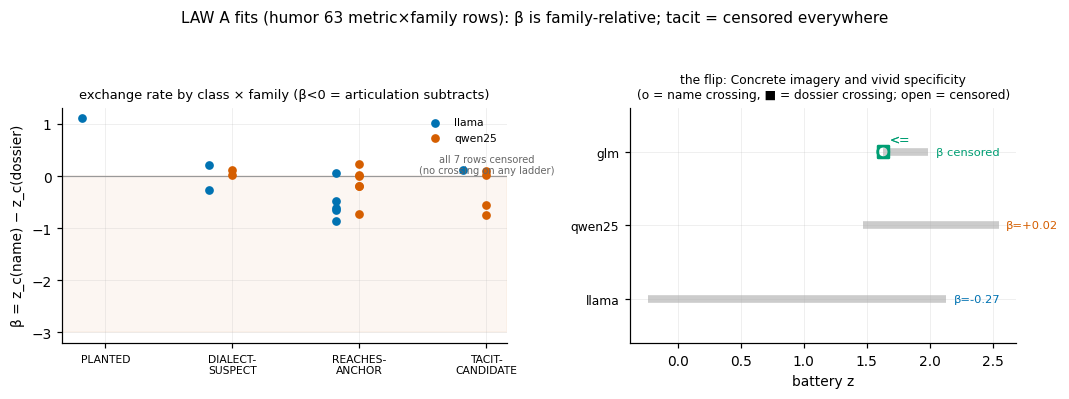

β defined: 21 / 63 rows; collapse-sensitive: 0 rows (interpret as form-limited)


In [36]:
zs = P["zxa_scaling"]
pm9 = zs["per_metric"]
FAMC9 = {"llama": "#0072B2", "qwen25": "#D55E00", "glm": "#009E73"}
def parse_cross(v):
    # returns (value, censor) with censor in {None, ">", "<="}
    if v is None: return None, None
    if isinstance(v, (int, float)): return float(v), None
    s = str(v)
    if s.startswith(">"): return float(s[1:]), ">"
    if s.startswith("<="): return float(s[2:]), "<="
    try: return float(s), None
    except Exception: return None, None
fig, (a, b) = plt.subplots(1, 2, figsize=(9.8, 3.4), gridspec_kw={"width_ratios": [1.15, 1]})
pref = ["PLANTED", "DIALECT-SUSPECT", "REACHES-AUDITED", "REACHES-ANCHOR", "TACIT-CANDIDATE"]
seen_cls = sorted(set(r["cls"] for r in pm9), key=lambda c: pref.index(c) if c in pref else 99)
cls_order = seen_cls
cpos = {c: i for i, c in enumerate(cls_order)}
a.axhspan(-3, 0, color="#D55E00", alpha=.05)
seenf = set()
for r in pm9:
    if r.get("beta") is None: continue
    x = cpos[r["cls"]] + {"llama": -.18, "qwen25": 0, "glm": .18}[r["family"]]
    a.scatter(x, r["beta"], s=22, color=FAMC9[r["family"]],
              label=r["family"] if r["family"] not in seenf else None, zorder=3)
    seenf.add(r["family"])
a.axhline(0, color="#999999", lw=.8)
n_cens = sum(1 for r in pm9 if r.get("beta") is None and r["cls"] == "TACIT-CANDIDATE")
a.text(cpos.get("TACIT-CANDIDATE", len(cls_order) - 1), .05,
       f"all {n_cens} rows censored\n(no crossing on any ladder)", ha="center", fontsize=6.5, color="#666666")
a.set_xticks(range(len(cls_order))); a.set_xticklabels([c.replace("-", "-\n") for c in cls_order], fontsize=7)
a.set_ylabel("β = z_c(name) − z_c(dossier)")
a.set_title("exchange rate by class × family (β<0 = articulation subtracts)", fontsize=8.5)
a.legend(fontsize=7, loc="upper right")
# --- flip exemplar: metric with defined β of opposite sign in ≥2 families (else max spread)
bybase = {}
for r in pm9:
    if r.get("beta") is not None:
        bybase.setdefault(r["base"], {})[r["family"]] = r
flip = None
for base, fams in bybase.items():
    bs = [v["beta"] for v in fams.values()]
    if len(bs) >= 2 and min(bs) < 0 < max(bs):
        if flip is None or (max(bs) - min(bs)) > flip[1]:
            flip = (base, max(bs) - min(bs))
if flip is None and bybase:
    flip = (max(bybase, key=lambda b: (len(bybase[b]), max(v["beta"] for v in bybase[b].values()) -
                                        min(v["beta"] for v in bybase[b].values()))), 0)
base = flip[0]
rows_f = {r["family"]: r for r in pm9 if r["base"] == base}
fams9 = [f for f in ["llama", "qwen25", "glm"] if f in rows_f]
for yi, fam in enumerate(fams9):
    lad = sorted(zs["families"][fam]["ladder"].values())
    b.plot([lad[0], lad[-1]], [yi, yi], color="#cccccc", lw=5, solid_capstyle="butt", zorder=1)
    r = rows_f[fam]
    for arm, mk in [("cross_name", "o"), ("cross_dossier", "s")]:
        v, cen = parse_cross(r.get(arm))
        if v is None: continue
        b.scatter(v, yi, s=55, marker=mk, zorder=3, color=FAMC9[fam],
                  facecolors="none" if cen else FAMC9[fam], linewidths=1.6)
        if cen: b.annotate(cen, (v, yi), textcoords="offset points", xytext=(4, 6), fontsize=8, color=FAMC9[fam])
    bt = r.get("beta")
    b.text(lad[-1] + .06, yi, f"β={bt:+.2f}" if bt is not None else "β censored",
           fontsize=7.5, va="center", color=FAMC9[fam])
b.set_yticks(range(len(fams9))); b.set_yticklabels(fams9, fontsize=8)
b.set_xlabel("battery z"); b.set_ylim(-.6, len(fams9) - .4)
b.set_title(f"the flip: {base[:44]}\n(o = name crossing, ■ = dossier crossing; open = censored)", fontsize=8)
fig.suptitle("LAW A fits (humor 63 metric×family rows): β is family-relative; tacit = censored everywhere", y=1.05, fontsize=10)
plt.tight_layout(); plt.show()
print("β defined:", sum(1 for r in pm9 if r.get("beta") is not None), "/ 63 rows;",
      "collapse-sensitive:", sum(1 for r in pm9 if r.get("collapse_sens")), "rows (interpret as form-limited)")

## 10. LAW B demonstration — curve shapes against the planted capability reference

One exemplar per shape (humor, 12 executors, frozen rendering). One empirical reference is drawn:

- **grey dotted — planted capability reference**: mean agreement on mechanical controls at the
  top-three capability-z executors. It estimates instrument performance at observed high capability;
  it is not a theorem-level ceiling for arbitrary bank metrics.

**How to read:** REACHES means the fitted bend overlaps this empirical reference. RISING remains
right-censored. BOUNDED means the fitted bend is below the reference and is a candidate for further
within-family and axis-sensitivity audit; it is not by itself a proof of inarticulability.


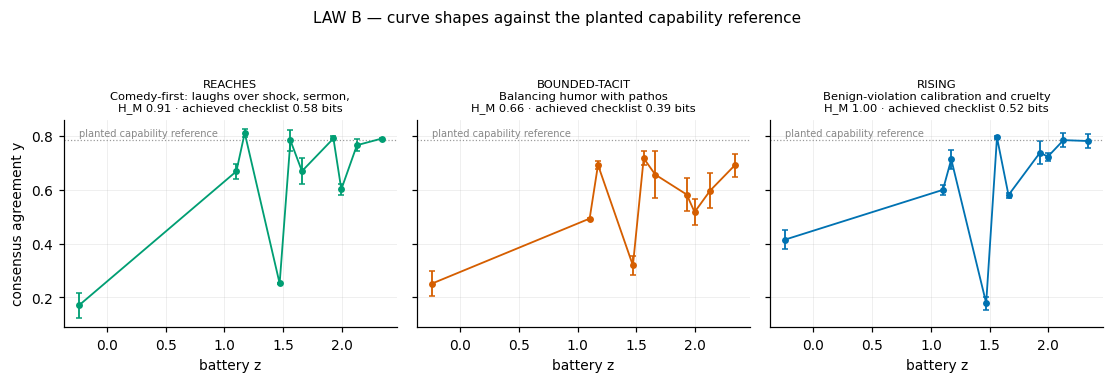

In [37]:
lb = P["lawB_demo"]
ec10 = {r["name"]: r for r in json.load(open("data/explain_curves.json"))["table"] if r["task"] == "humor"}

fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.2), sharey=True)
lab2col = {"REACHES": VC["REACHES"], "BOUNDED-TACIT": VC["BOUNDED"], "RISING": VC["RISING"]}
for ax, (lab, e) in zip(axes, lb.items()):
    cv = e["curve"]
    z, y = np.array(cv["z"]), np.array(cv["y"])
    se = cv.get("se") or cv.get("yerr")
    col = lab2col[lab]
    if se: ax.errorbar(z, y, yerr=[s if s is not None else 0 for s in se], color=col,
                       marker="o", ms=3.5, lw=1.2, capsize=2)
    else:  ax.plot(z, y, color=col, marker="o", ms=3.5, lw=1.2)
    ax.axhline(ceil, color="#999999", lw=.8, ls=":")
    ax.text(z.min(), ceil + .012, "planted capability reference", fontsize=6.5, color="#888888")
    row = ec10.get(e["name"])
    ax.set_title("%s\n%s\nH_M %.2f · achieved checklist %.2f bits" % (
        lab, e["name"][:40], row.get("H_M", float("nan")) if row else float("nan"),
        row.get("opt_omega_bits", float("nan")) if row else float("nan")), fontsize=7.5)
    ax.set_xlabel("battery z")
axes[0].set_ylabel("consensus agreement y")
fig.suptitle("LAW B — curve shapes against the planted capability reference", y=1.07, fontsize=10)
plt.tight_layout(); plt.show()

## 11. Achieved checklist score × executor-family curves

**A1 (M_ω / OPT direction)**: per-metric OPT_Ω = achieved subset-composition of the mined unit pool,
in recovery bits. It is not a within-executor channel upper bound; pool saturation was not established.
**A2 (z×a direction)**: per-(metric×family) transmissibility — dossier-vs-name gain at the top
(`top_gap`), exchange rate β, and the tacit verdict (no arm works, frontier κ≈0).

**Join (humor, 48 metric×family rows):**
- ρ(OPT_Ω, top_gap) = **+.34** (p=.019) — achieved checklist recovery covaries with dossier gain in
  this sample. This is an association between two measured instruments, not agreement between bounds.
- **The inversion**: A2 TACIT-CANDIDATES have *higher* A1 OPT_Ω than the rest (median .45 vs .24,
  AUC .92, p=.001; n=4 base metrics — exploratory). These rows have high achieved within-executor
  checklist recovery but low cross-speaker convergence; the design does not identify tacitness as the cause.
- ρ(OPT_Ω, β) = −.17 (n.s., n=20) — the exchange *rate* is family-relative and doesn't reduce
  to channel capacity.

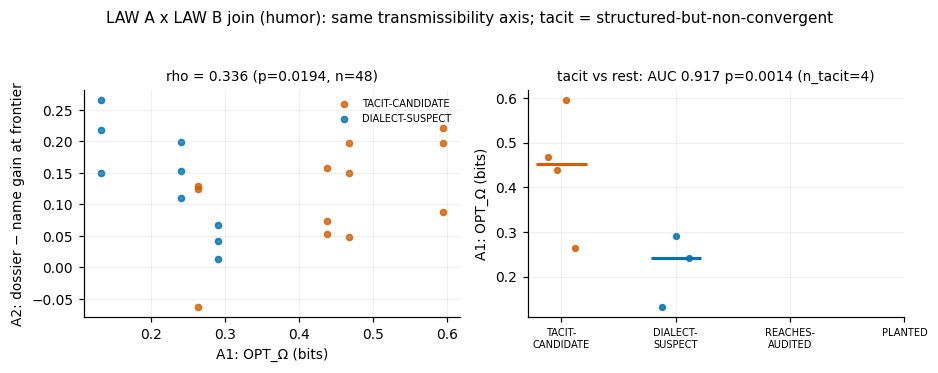

COVERAGE — Law B fleet: {'code_review': '138m x 12e', 'creative_writing': '374m x 15e', 'humor_sup': '132m x 14e', 'math': '146m x 15e', 'news_homepages': '155m x 15e', 'notice_and_comment': '93m x 15e', 'patents': '12m x 14e', 'peer_review': '93m x 15e', 'press_releases': '225m x 15e'}
COVERAGE — A1 OPT_Ω per task: {'humor': 261, 'creative_writing': 362, 'math': 127, 'press_releases': 195, 'news_homepages': 88, 'peer_review': 78, 'notice_and_comment': 18, 'patents': 6}
COVERAGE — A2 z×a: {'news_homepages': '16m x 2fam', 'humor': '21m x 3fam'}


In [38]:
j = P["a1a2_join"]; jrows = [r for r in j["rows"] if r["top_gap"] is not None]
CLC = {"TACIT-CANDIDATE": VC["BOUNDED"], "DIALECT-SUSPECT": VC["RISING"],
       "REACHES-AUDITED": VC["REACHES"], "PLANTED": "#999999"}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.6, 3.2))
for cls, col in CLC.items():
    rr = [r for r in jrows if r["cls"] == cls]
    if not rr: continue
    a1.scatter([r["opt_omega_bits"] for r in rr], [r["top_gap"] for r in rr],
               s=16, color=col, label=cls, alpha=.8)
st = j["stats"]["rho_opt_vs_topgap"]
a1.set_xlabel("A1: OPT_Ω (bits)"); a1.set_ylabel("A2: dossier − name gain at frontier")
a1.set_title("rho = %s (p=%s, n=%s)" % (st["rho"], st["p"], st["n"]), fontsize=9)
a1.legend(fontsize=6.5)
pos = {c: i for i, c in enumerate(CLC)}
for cls, col in CLC.items():
    vals = sorted(set((r["base"], r["opt_omega_bits"]) for r in j["rows"] if r["cls"] == cls))
    v = [x[1] for x in vals]
    if not v: continue
    a2.scatter(np.full(len(v), pos[cls]) + np.linspace(-.12, .12, len(v)), v, s=14, color=col, alpha=.85)
    a2.hlines(np.median(v), pos[cls] - .22, pos[cls] + .22, color=col, lw=2)
mw = j["stats"].get("tacit_vs_rest_opt", {})
a2.set_xticks(range(len(CLC))); a2.set_xticklabels([c.replace("-", "-\n") for c in CLC], fontsize=6.5)
a2.set_ylabel("A1: OPT_Ω (bits)")
a2.set_title("tacit vs rest: AUC %s p=%s (n_tacit=%s)" % (mw.get("auc"), mw.get("p"), mw.get("n_tacit")), fontsize=9)
fig.suptitle("LAW A x LAW B join (humor): same transmissibility axis; tacit = structured-but-non-convergent", y=1.04, fontsize=10)
plt.tight_layout(); plt.show()
cov = P["coverage"]
print("COVERAGE — Law B fleet:", {t: "%dm x %de" % (v["metrics"], v["executors"]) for t, v in cov["fleet_B"].items()})
print("COVERAGE — A1 OPT_Ω per task:", cov["A1_opt_omega"])
print("COVERAGE — A2 z×a:", {t: "%dm x %dfam" % (v["metrics"], len(v["families"])) for t, v in cov["A2_zxa"].items()})

### 11b. LAW A (A1) multi-task census — per-metric OPT_Ω across 8 tasks

The A1 program is not humor-only: **1,137 metrics across 8 tasks** carry a per-metric achieved OPT_Ω
(selected unit-subset recovery, bits). Left: the
distribution by task (the A1 coverage map). Right: OPT_Ω grouped by the metric's LAW-B curve
verdict, pooled across tasks — the two laws' verdicts are correlated but far from redundant
(REACHES metrics tend to carry more re-articulable structure; RISING/NOISY sit lower; BOUNDED
spreads wide). These are descriptive cross-instrument associations.
Single-metric anatomy of A1 (GEPA trajectory, fixed-target DPI cap, unit decomposition, k-subset
OPT_Ω construction) lives in the companion notebook
`2026-07-03__prompt-optimality-gepa-vs-ceiling.ipynb`; N&C 40-rule + definitive peer-review A1
measurements are documented there.

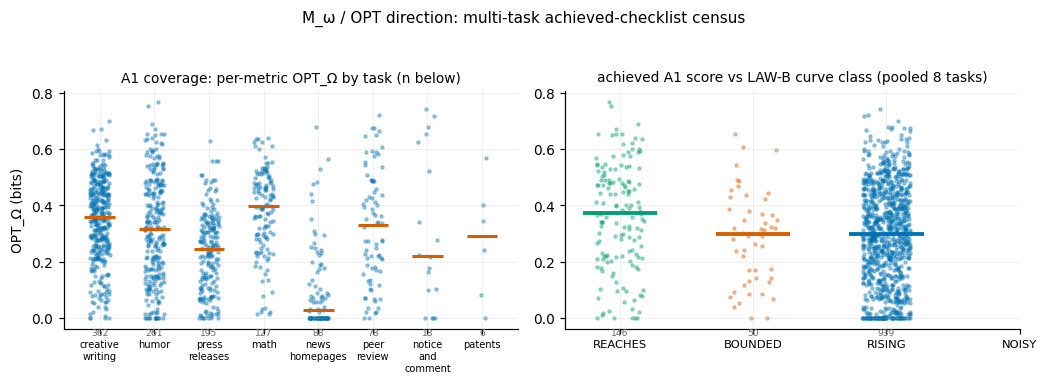

A1 census: {'humor': 261, 'creative_writing': 362, 'math': 127, 'press_releases': 195, 'news_homepages': 88, 'peer_review': 78, 'notice_and_comment': 18, 'patents': 6}


In [39]:
ecfull = json.load(open("data/explain_curves.json"))["table"]
rows_a1 = [r for r in ecfull if r.get("opt_omega_bits") is not None]
tasks_a1 = sorted(set(r["task"] for r in rows_a1), key=lambda t: -sum(1 for r in rows_a1 if r["task"] == t))
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 3.3))
for ti, t in enumerate(tasks_a1):
    v = np.array([r["opt_omega_bits"] for r in rows_a1 if r["task"] == t])
    xj = np.full(len(v), ti) + np.random.RandomState(0).uniform(-.18, .18, len(v))
    a.scatter(xj, v, s=4, alpha=.35, color="#0072B2")
    a.hlines(np.median(v), ti - .28, ti + .28, color="#D55E00", lw=2)
    a.text(ti, -.06, str(len(v)), ha="center", fontsize=6, color="#666666")
a.set_xticks(range(len(tasks_a1)))
a.set_xticklabels([t.replace("_", "\n") for t in tasks_a1], fontsize=6.5)
a.set_ylabel("OPT_Ω (bits)"); a.set_title("A1 coverage: per-metric OPT_Ω by task (n below)", fontsize=9)
vorder = ["REACHES", "BOUNDED", "RISING", "NOISY"]
for vi, vd in enumerate(vorder):
    v = np.array([r["opt_omega_bits"] for r in rows_a1 if r.get("verdict") == vd])
    if not len(v): continue
    xj = np.full(len(v), vi) + np.random.RandomState(1).uniform(-.18, .18, len(v))
    b.scatter(xj, v, s=4, alpha=.35, color=VC.get(vd, "#999999"))
    b.hlines(np.median(v), vi - .28, vi + .28, color=VC.get(vd, "#999999"), lw=2.5)
    b.text(vi, -.06, str(len(v)), ha="center", fontsize=6, color="#666666")
b.set_xticks(range(len(vorder))); b.set_xticklabels(vorder, fontsize=7.5)
b.set_title("achieved A1 score vs LAW-B curve class (pooled 8 tasks)", fontsize=9)
fig.suptitle("M_ω / OPT direction: multi-task achieved-checklist census", y=1.04, fontsize=10)
plt.tight_layout(); plt.show()
import collections as _cl
print("A1 census:", dict(_cl.Counter(r["task"] for r in rows_a1)))

## 12. Cross-task frontier step-down — and the divergence-toward-truth proof

The humor step-down (glm-4.7 → 5.2 loses −.18 crowd agreement) tested on three more tasks
against each task's own frozen 14-executor mid-scale crowd. **The step is task-relative**: it
appears where the frontier has passed the *crowd's* competence on that battery, not at a
universal capability level.

**The math panel carries the mechanism proof**: glm-5.2's planted *crowd-agreement* fell −.09
while its planted *truth*-accuracy **rose** +.03 — against a crowd only .68-competent at
mechanical checks. The frontier disagrees exactly where the crowd errs (PLANTED-quote:
glm-4.7 truth .34 → glm-5.2 .69). Falling agreement above the crowd's competence is
**divergence toward truth**, not degradation.

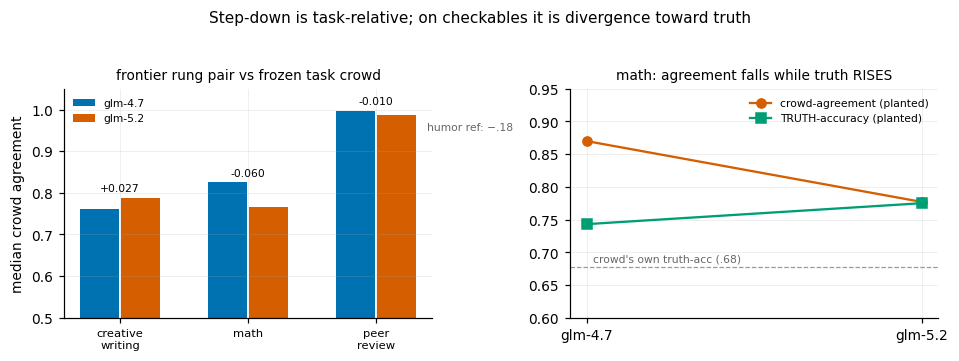

In [40]:
ct = json.load(open("data/crosstask_glm_stepdown.json"))
# math planted truth-accuracy (adjudicate_crosstask + planted_metrics regen, 2026-07-10):
truth = {"glm-47": .743, "glm-52": .775, "crowd": .678}
agr_planted_math = {"glm-47": .870, "glm-52": .777}
fig, (a, b) = plt.subplots(1, 2, figsize=(8.8, 3.1))
tasks = list(ct.keys()); x = np.arange(len(tasks))
g47 = [ct[t]["glm-47"] for t in tasks]; g52 = [ct[t]["glm-52"] for t in tasks]
a.bar(x - .16, g47, .3, color="#0072B2", label="glm-4.7")
a.bar(x + .16, g52, .3, color="#D55E00", label="glm-5.2")
for i, t in enumerate(tasks):
    a.text(i, max(g47[i], g52[i]) + .015, "%+.3f" % ct[t]["delta_52_minus_47"], ha="center", fontsize=7)
a.text(len(tasks) - .6, .95, "humor ref: −.18", fontsize=7, color="#666666")
a.set_xticks(x); a.set_xticklabels([t.replace("_", "\n") for t in tasks], fontsize=7.5)
a.set_ylabel("median crowd agreement"); a.set_ylim(.5, 1.05); a.legend(fontsize=7)
a.set_title("frontier rung pair vs frozen task crowd", fontsize=9)
b.plot([0, 1], [agr_planted_math["glm-47"], agr_planted_math["glm-52"]], "o-", color="#D55E00", label="crowd-agreement (planted)")
b.plot([0, 1], [truth["glm-47"], truth["glm-52"]], "s-", color="#009E73", label="TRUTH-accuracy (planted)")
b.axhline(truth["crowd"], color="#999999", ls="--", lw=.8)
b.text(.02, truth["crowd"] + .008, "crowd's own truth-acc (.68)", fontsize=7, color="#666666")
b.set_xticks([0, 1]); b.set_xticklabels(["glm-4.7", "glm-5.2"])
b.set_ylim(.6, .95); b.legend(fontsize=7)
b.set_title("math: agreement falls while truth RISES", fontsize=9)
fig.suptitle("Step-down is task-relative; on checkables it is divergence toward truth", y=1.04, fontsize=10)
plt.tight_layout(); plt.show()

## 13. A compute axis — params × training tokens (the OSL family-free candidate)

Public model cards give N (params) and D (pretraining tokens); C ≈ 6·N·D approximates training
FLOPs — the axis OSL work extrapolates along. Two-stage read: **compute → capability (z)** is
family-specific (panel left: same compute, different z — capability efficiency differs), and
**capability → articulability (y)** is the shared stage our instrument measures (§7b). To
forecast a *future family* you need its compute→z efficiency (one battery run), after which the
z→y surface here applies.

Token counts (public cards): Llama-3.2 1B/3B ≈ 9T · Llama-3.1 8B/70B ≈ 15.6T · Qwen2.5 ≈ 18T ·
Gemma-2 9B = 8T / 27B = 13T · Phi-4 ≈ 9.8T (synthetic-heavy — expected off-trend).
Mistral & GLM/Kimi/DeepSeek: undisclosed → excluded (the honest limit of the public-info axis).

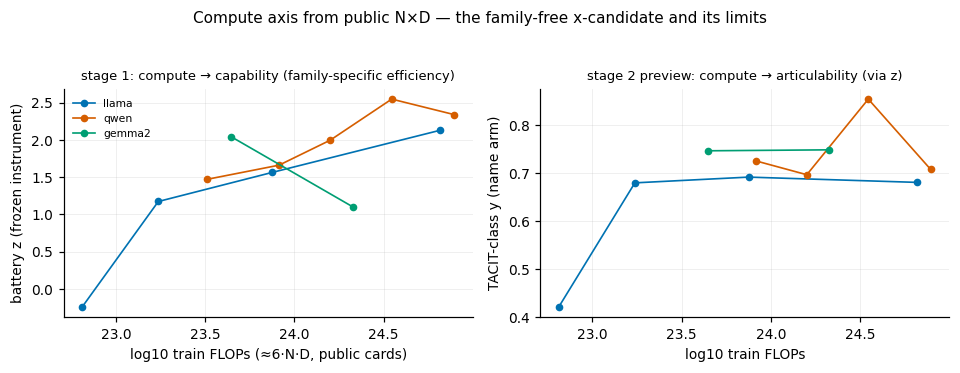

capability efficiency at matched compute: same log-FLOPs, different z -> compute alone
does NOT collapse families; battery-z (or planted truth-acc) stays the working x-axis.


In [41]:
PAR = {"llama1b": 1.2e9, "llama3b": 3.2e9, "llama8b": 8e9, "llama70b": 70e9,
       "qwen25-3b": 3e9, "qwen25-7b": 7.6e9, "qwen25-14b": 14.7e9, "qwen25-32b": 32.5e9,
       "qwen25-72b": 72.7e9, "gemma2-9b": 9.2e9, "gemma2-27b": 27.2e9, "phi4": 14.7e9}
TOK = {"llama1b": 9e12, "llama3b": 9e12, "llama8b": 15.6e12, "llama70b": 15.6e12,
       "qwen25-3b": 18e12, "qwen25-7b": 18e12, "qwen25-14b": 18e12, "qwen25-32b": 18e12,
       "qwen25-72b": 18e12, "gemma2-9b": 8e12, "gemma2-27b": 13e12, "phi4": 9.8e12}
FAMC = {"llama": "#0072B2", "qwen": "#D55E00", "gemma2": "#009E73", "phi": "#CC79A7"}
fam_of = lambda e: ("llama" if e.startswith("llama") else "qwen" if e.startswith("qwen")
                    else "gemma2" if e.startswith("gemma2") else "phi")
fig, (a, b) = plt.subplots(1, 2, figsize=(8.8, 3.2))
tacname = la["y_ref"].get("TACIT-CANDIDATE|name", {})
for fam in ["llama", "qwen", "gemma2", "phi"]:
    es = sorted([e for e in PAR if fam_of(e) == fam and e in zmap and zmap[e] is not None],
                key=lambda e: 6 * PAR[e] * TOK[e])
    if not es: continue
    C = [np.log10(6 * PAR[e] * TOK[e]) for e in es]
    a.plot(C, [zmap[e] for e in es], "o-", color=FAMC[fam], ms=4, lw=1.1, label=fam)
    es2 = [e for e in es if e in tacname and not degen.get(e)]
    b.plot([np.log10(6 * PAR[e] * TOK[e]) for e in es2], [tacname[e] for e in es2],
           "o-", color=FAMC[fam], ms=4, lw=1.1, label=fam)
a.set_xlabel("log10 train FLOPs (≈6·N·D, public cards)"); a.set_ylabel("battery z (frozen instrument)")
a.set_title("stage 1: compute → capability (family-specific efficiency)", fontsize=8.5); a.legend(fontsize=7)
b.set_xlabel("log10 train FLOPs"); b.set_ylabel("TACIT-class y (name arm)")
b.set_title("stage 2 preview: compute → articulability (via z)", fontsize=8.5)
fig.suptitle("Compute axis from public N×D — the family-free x-candidate and its limits", y=1.04, fontsize=10)
plt.tight_layout(); plt.show()
print("capability efficiency at matched compute: same log-FLOPs, different z -> compute alone")
print("does NOT collapse families; battery-z (or planted truth-acc) stays the working x-axis.")

## Reading guide & caveats

1. **Verdicts are the robust readout**; individual L CIs are wide at ≤12 points per curve.
2. **BOUNDED is provisional** until the frontier probe points (Llama-405B, GLM-4.7→5.2) land —
   the Beta-IRT cross-check showed a no-ceiling model wins LOEO, so battery-axis compression can
   mimic plateaus.
3. **Family dialects** dominate residuals (§6) — never read a bend off a pooled curve without
   checking the within-family ladders (Llama/Qwen, 4 rungs each).
4. Planted lines are empirical capability references, not theorem-level ceilings for bank metrics. A task
   without landed planted curves has no BOUNDED/REACHES reference split.
5. Everything here is reconstruction-only: silver labels appear exclusively in evaluate-only
   readouts (§4–5), never in metric construction.
6. Refresh: set `REFRESH=True` in the load cell (fleet task #136 writes
   `outputs/osl_multi/mbar2_*.npz`; `panel_analysis.py <task>` regenerates the jsons).